# 🤖 Project Budget & Duration Predictor
Predicts **final_budget_usd** and from project features.

Prices are normalized to **USD** (via the daily `usd_rate`) instead of raw IRR,
since IRR has been too unstable over this dataset's ~15-year span to be a
meaningful regression target on its own.

Sections:
1. Load & inspect
2. Target engineering (USD normalization, null handling, log transform)
3. Sample weighting types
4. Feature engineering & encoding
5. Train models — classical ML CatBoost
6. Train a deep learning model (feed-forward neural net)
7. Analysis
8. Feature importance (classical models)
9. SHAP — per-prediction explanations
10. Use embedding

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
ACCENT, ACCENT2 = '#5B8DEF', '#F4845F'

# ── Paths ────────────────────────────────────────────────────────────────
CSV_PATH = Path('../ml_dataset/full_dataset.csv')   # <-- adjust if needed
# CSV_PATH = Path('/absolute/path/to/full_dataset.csv')

BUDGET_RATIO_THRESHOLD = 0.3 # max/min ratio to accept imputed budget (avg of min/max)

# Only rows with a resolvable USD exchange rate can have a USD target.
# (build_dataset.py already computes this from the nearest available
# daily rate, average of open/high/low/close, keyed off scraped_date_created.)
REQUIRE_USD_RATE = True

ENUM_COLS = [
    'project_type', 'ai_level', 'business_logic', 'data_volume',
    'integration_complexity', 'ui_complexity', 'algorithmic_complexity'
]
# Columns that are not model inputs
NON_FEATURE = [
    'project_id',"scraped_project_id",'title','category','organization','created_at','scraped_date_created',
    'final_budget','log_final_budget','budget_min','budget_max','log_budget_min','log_budget_max',
    'budget_range','budget_range_ratio','has_final_budget','duration',
    'description','skills','outer_link','updated_at','category_scraped_id','description_length',
     'description_word_count', 'skill_count',
    "website","web_application",
      "mobile_application","desktop_application",
      "api_backend","ecommerce",
      "marketplace","cms","crm","erp",
      "lms","booking_system",
      "social_network","media_platform",
      "financial_system","healthcare_system",
      "real_estate_platform","automation_system",
      "iot_system","ai_application",
      "browser_extension","other",
      'external_api_count','estimated_screens','estimated_entities',
    #   'requires_refactoring','requires_reverse_engineering','cross_platform',
    # 'ai_level','business_logic','data_volume','integration_complexity','ui_complexity','algorithmic_complexity',
    'feature_score_sum',
    # 'feature_count',
    'feature_score_mean','feature_score_max',

    # USD normalization columns (rate + amounts) — inputs to target engineering,
    # not model features themselves
    'usd_rate','usd_rate_date','final_budget_usd','log_final_budget_usd',
    'budget_min_usd','budget_max_usd','log_budget_min_usd','log_budget_max_usd',
    'budget_range_usd',
    # derived targets added later
    'target_budget','is_budget_imputed','is_days_null',
    'log_target_budget',
]


def interval_accuracy(y_true_log, y_pred_log, pct=0.20):
    """
    Percentage of predictions within ±pct of the true price.
    Inputs are log1p(price).
    """

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rel_error = np.abs(y_pred - y_true) / np.maximum(y_true, 1)

    return np.mean(rel_error <= pct)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_raw = pd.read_csv(CSV_PATH)
print(f'✅  {len(df_raw):,} rows  ·  {df_raw.shape[1]} columns')
print(f'    Organizations: {df_raw.organization.unique()}')

if REQUIRE_USD_RATE and 'usd_rate' in df_raw.columns:
    n_no_rate = df_raw['usd_rate'].isna().sum()
    print(f'    Rows with no usable USD rate (dropped before modeling): '
          f'{n_no_rate:,} ({n_no_rate/len(df_raw):.1%})')

df_raw.head(2)
print(df_raw.columns.tolist())

d:\PROGRAMMING\Web\Final Project\KarChandV2\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅  19,668 rows  ·  165 columns
    Organizations: <StringArray>
['Karlancer', 'Ponisha']
Length: 2, dtype: str
    Rows with no usable USD rate (dropped before modeling): 0 (0.0%)
['project_id', 'scraped_project_id', 'title', 'category', 'organization', 'outer_link', 'created_at', 'scraped_date_created', 'usd_rate', 'usd_rate_date', 'final_budget', 'log_final_budget', 'final_budget_usd', 'log_final_budget_usd', 'budget_min', 'budget_max', 'log_budget_min', 'log_budget_max', 'budget_min_usd', 'budget_max_usd', 'log_budget_min_usd', 'log_budget_max_usd', 'budget_range_usd', 'budget_range_ratio', 'has_final_budget', 'duration', 'duration_days', 'description_length', 'description_word_count', 'skill_count', 'skills', 'description', 'Authentication', 'Authorization & Role Management', 'User Management', 'User Profiles', 'Infrastructure & Operations', 'Administration Panel', 'Dashboard', 'Settings & Configuration', 'Content Management', 'Rich Text Editing', 'Media Management', 'Forms & Data 

## 2 · Target engineering
**USD normalization:** every budget figure is converted from IRR to USD using
`usd_rate` (nearest available daily rate) *before* any null-handling. Rows with
no resolvable `usd_rate` are dropped — we can't meaningfully price a project
without knowing what its IRR figure was worth at the time.

**Budget null rule:** if `final_budget_usd` is null and `budget_max_usd / budget_min_usd ≤ threshold` → use average of min/max. Otherwise drop the row.

**Duration null rule:** fill with dataset median, add `is_days_null` flag so the model knows the value was imputed.

Rows dropped (no USD rate): 0
Rows before: 19,668  |  dropped (ratio too high): 6562  |  kept: 13,106
Budget imputed (avg min/max): 281
Duration filled with median (5 days): 6456



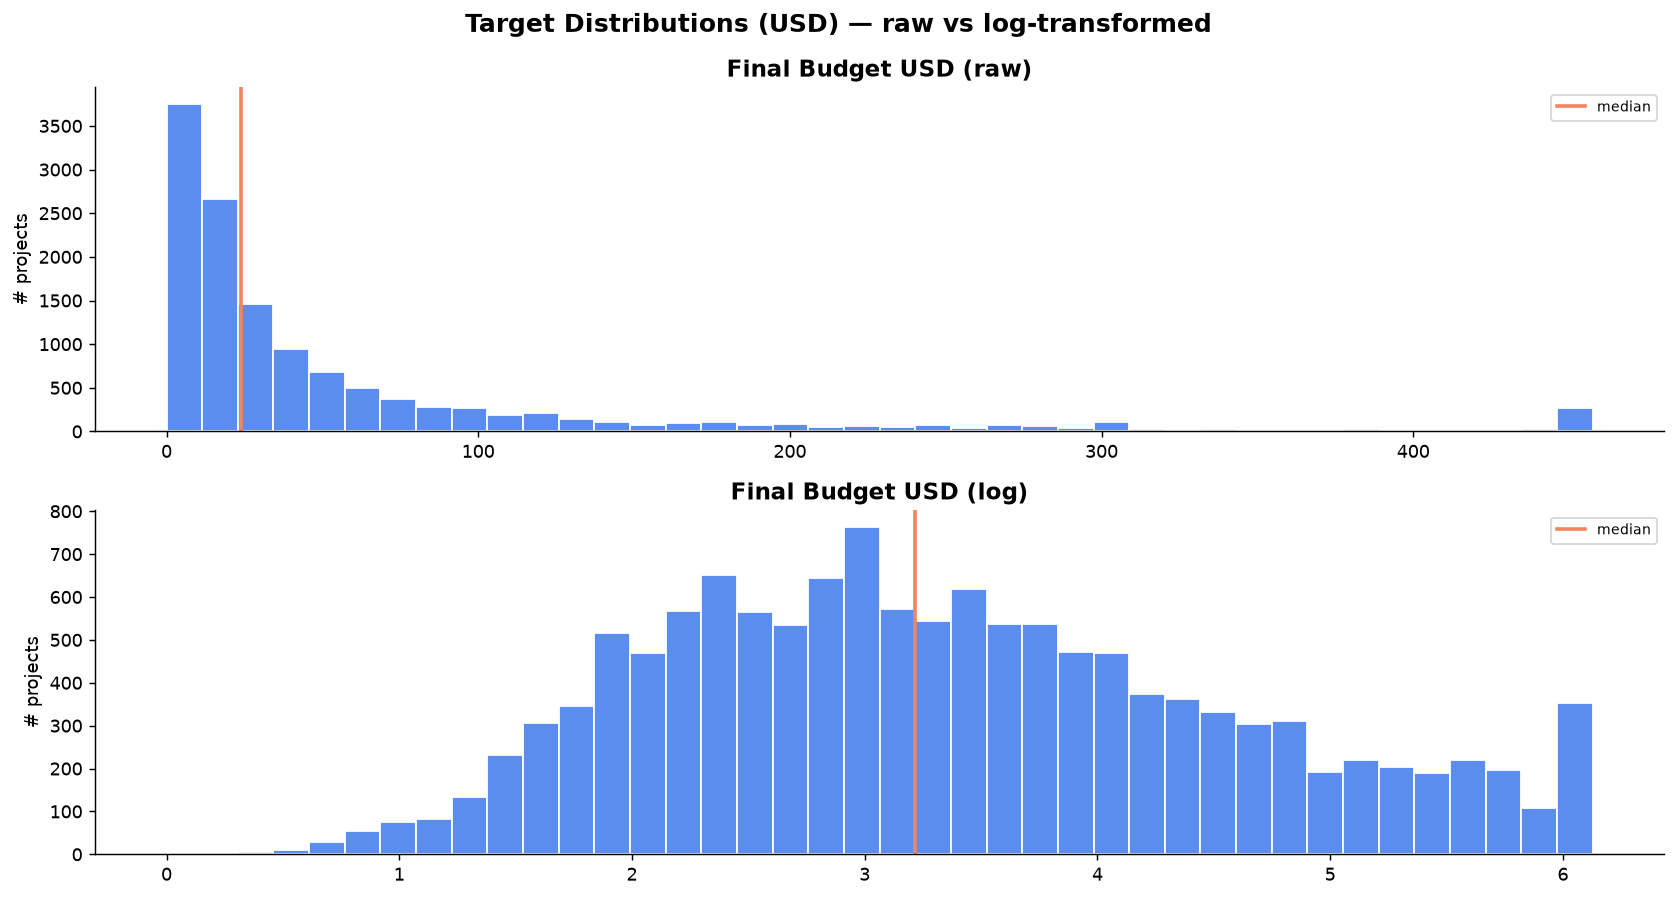

In [2]:
# Drop rows with no usable USD rate first — everything downstream is USD-denominated.
df = df_raw[df_raw['usd_rate'].notna()].copy() if REQUIRE_USD_RATE else df_raw.copy()
n_dropped_no_rate = len(df_raw) - len(df)
PCT_THRESHOLD = 0.10
PRICE_THRESHOLD_UP = 1000000
PRICE_THRESHOLD_DOWN = 0
# ── Budget (USD) ─────────────────────────────────────────────────────────
def resolve_final_budget(row):
    if row['final_budget_usd'] > PRICE_THRESHOLD_UP or row['final_budget_usd'] < PRICE_THRESHOLD_DOWN :
        return np.nan, False 
    if pd.notna(row['final_budget_usd']) and row["final_budget_usd"] != 0 and not row['final_budget_usd'] < row['budget_min_usd'] * (1 - PCT_THRESHOLD):
        return row['final_budget_usd'], False   # (value, is_imputed)
    ratio = row['budget_max_usd'] / max(row['budget_min_usd'], 1e-6)
    if ratio <= BUDGET_RATIO_THRESHOLD:
        estimated_final_price =  (row['budget_min_usd'] + row['budget_max_usd']) / 2
        if estimated_final_price > PRICE_THRESHOLD_UP or estimated_final_price < PRICE_THRESHOLD_DOWN :
            return np.nan, False 
        return estimated_final_price, True
    # return np.nan, False   # ratio too high → will be dropped

df[['target_budget', 'is_budget_imputed']] = df.apply(
    lambda r: pd.Series(resolve_final_budget(r)), axis=1
)
before = len(df)
df = df[df['target_budget'].notna()].copy()
dropped = before - len(df)

# ── Duration ─────────────────────────────────────────────────────────────
duration_median = df['duration_days'].median()
df['is_days_null'] = df['duration_days'].isna().astype(int)
df['duration_days'] = df['duration_days'].fillna(duration_median)

# ── Log-transform targets (right-skewed money/time values) ────────────────
df['log_target_budget']   = np.log1p(df['target_budget'])

print(f'Rows dropped (no USD rate): {n_dropped_no_rate:,}')
print(f'Rows before: {before:,}  |  dropped (ratio too high): {dropped}  |  kept: {len(df):,}')
print(f'Budget imputed (avg min/max): {df.is_budget_imputed.sum()}')
print(f'Duration filled with median ({duration_median:.0f} days): {df.is_days_null.sum()}')
print()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, col, label in [
    (axes[0], 'target_budget',       'Final Budget USD (raw)'),
    (axes[1], 'log_target_budget',   'Final Budget USD (log)'),
]:
    ax.hist(df[col].clip(upper=df[col].quantile(0.98)), bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(df[col].median(), color=ACCENT2, linewidth=2, label='median')
    ax.set_title(label); ax.set_ylabel('# projects'); ax.legend(fontsize=8)
fig.suptitle('Target Distributions (USD) — raw vs log-transformed', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Sample Weighting Types

In [3]:
import json
import numpy as np
import pandas as pd

# ============================================================
# Load confidence feature names from taxonomy
# ============================================================

with open("taxonomy/taxonomy.json", "r", encoding="utf-8") as f:
    taxonomy = json.load(f)

CONFIDENCE_FEATURES = [
    c for c in list(taxonomy["features"]["values"])
    if c in df_raw.columns
]

print(df_raw.columns)

print(f"Found {len(CONFIDENCE_FEATURES)} confidence features.")

# ============================================================
# Confidence preprocessing
# ============================================================

# Available modes:
#
# A      -> Keep original (0,1,2,3,4,5)
# B      -> Remove weak detections (1,2 -> 0)
# C      -> Binary presence (3,4,5 -> 1)
# MAP    -> Manual nonlinear mapping
# POWER  -> (confidence / 5)^2

CONFIDENCE_MAP = {
    0: 0.00,
    1: 0.02,
    2: 0.08,
    3: 0.35,
    4: 0.75,
    5: 1.00,
}


def transform_confidence(df, mode="A"):
    """
    Transform only taxonomy confidence features.

    Parameters
    ----------
    df : pandas.DataFrame

    mode : str
        "A"      -> original
        "B"      -> 1,2 become 0
        "C"      -> binary (>=3 -> 1)
        "MAP"    -> manual nonlinear mapping
        "POWER"  -> (x/5)^2

    Returns
    -------
    pandas.DataFrame
    """

    df = df.copy()

    mode = mode.upper()

    if mode == "A":
        pass

    elif mode == "B":

        df[CONFIDENCE_FEATURES] = df[CONFIDENCE_FEATURES].replace({
            1: 0,
            2: 0,
        })

    elif mode == "C":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES] >= 3
        ).astype(np.int8)

    elif mode == "MAP":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES]
            .replace(CONFIDENCE_MAP)
            .astype(np.float32)
        )

    elif mode == "POWER":

        df[CONFIDENCE_FEATURES] = (
            (df[CONFIDENCE_FEATURES] / 5.0) ** 2
        ).astype(np.float32)

    else:
        raise ValueError(f"Unknown mode '{mode}'")

    return df

Index(['project_id', 'scraped_project_id', 'title', 'category', 'organization',
       'outer_link', 'created_at', 'scraped_date_created', 'usd_rate',
       'usd_rate_date',
       ...
       'data_volume', 'integration_complexity', 'ui_complexity',
       'algorithmic_complexity', 'updated_at', 'category_scraped_id',
       'feature_score_sum', 'feature_count', 'feature_score_mean',
       'feature_score_max'],
      dtype='str', length=165)
Found 82 confidence features.


## 4 · Feature engineering & encoding

In [4]:


# ============================================================
# Ordered categorical columns
# ============================================================

PROJECT_TYPE_COL = "project_type"

ORDINAL_COLS = [
    "ai_level",
    "business_logic",
    "data_volume",
    "integration_complexity",
    "ui_complexity",
    "algorithmic_complexity",
]

ENUM_ORDER = {
    "ai_level": ["none", "basic", "advanced"],
    "business_logic": ["low", "medium", "high"],
    "data_volume": ["small", "medium", "large"],
    "integration_complexity": ["low", "medium", "high"],
    "ui_complexity": ["low", "medium", "high"],
    "algorithmic_complexity": ["low", "medium", "high"],
}

# ============================================================
# Keep only columns that exist and are used as features
# ============================================================

ordinal_cols_present = [
    c for c in ORDINAL_COLS
    if c in df.columns and c not in NON_FEATURE
]

project_type_present = (
    [PROJECT_TYPE_COL]
    if PROJECT_TYPE_COL in df.columns and PROJECT_TYPE_COL not in NON_FEATURE
    else []
)

cols_to_clean = ordinal_cols_present + project_type_present

# ============================================================
# Normalize string values
# ============================================================

if cols_to_clean:
    df[cols_to_clean] = (
        df[cols_to_clean]
        .astype(str)
        .apply(lambda s: s.str.strip().str.lower())
    )

# ============================================================
# Show values before encoding
# ============================================================

print("=== Enum values before encoding ===")

for col in cols_to_clean:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(20))

# ============================================================
# Ordinal encode ordered columns
# ============================================================

if ordinal_cols_present:

    enc = OrdinalEncoder(
        categories=[ENUM_ORDER[c] for c in ordinal_cols_present],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    df[ordinal_cols_present] = enc.fit_transform(
        df[ordinal_cols_present]
    )

# ============================================================
# One-hot encode project_type
# ============================================================

if project_type_present:

    df = pd.get_dummies(
        df,
        columns=project_type_present,
        prefix="project_type",
        dtype=np.int8,
    )

# ============================================================
# Build feature list
# ============================================================

ALL_FEATURES = [
    c
    for c in df.columns
    if c not in NON_FEATURE and df[c].dtype != object
]

print(f"\nNumber of features: {len(ALL_FEATURES)}")

# ============================================================
# Prepare train/test
# ============================================================
MODE="A"
df_model = transform_confidence(df, MODE)

X = df_model[ALL_FEATURES]
yB = df_model["log_target_budget"]

# First split: separate out test (held out, touched once)
X_temp, X_te, yB_temp, yB_te = train_test_split(
    X,
    yB,
    test_size=0.15,
    random_state=42,
)

# Second split: divide remainder into train / validation
X_tr, X_val, yB_tr, yB_val = train_test_split(
    X_temp,
    yB_temp,
    test_size=0.1765,  # 0.1765 * 0.85 ≈ 0.15 → 70/15/15 overall
    random_state=42,
)

print(f"Train: {len(X_tr)} ({len(X_tr)/len(X):.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X):.1%})")
print(f"Test:  {len(X_te)} ({len(X_te)/len(X):.1%})")

print(X_te.head(2))

=== Enum values before encoding ===

ai_level
ai_level
none        12442
advanced      457
basic         207
Name: count, dtype: int64

business_logic
business_logic
low       8115
medium    4119
high       872
Name: count, dtype: int64

data_volume
data_volume
small     10098
medium     2715
large       293
Name: count, dtype: int64

integration_complexity
integration_complexity
low       10770
medium     2046
high        290
Name: count, dtype: int64

ui_complexity
ui_complexity
low       9118
medium    3540
high       448
Name: count, dtype: int64

algorithmic_complexity
algorithmic_complexity
low       10503
medium     1827
high        776
Name: count, dtype: int64

project_type
project_type
new             7097
maintenance     3184
bugfix          1582
optimization     577
migration        348
consulting       303
testing           15
Name: count, dtype: int64

Number of features: 110
Train: 9173 (70.0%)
Val:   1967 (15.0%)
Test:  1966 (15.0%)
       duration_days  Authentication 

## Linear Regression


LinearRegression_None
Weight mode    : none
Train R²       : 0.4083
Test  R²       : 0.3981
RMSE (log)     : 0.9760
MAE            : 50
Coverage ±10% : 7.93%
Coverage ±20% : 15.46%
Coverage ±30% : 23.91%
Coverage ±50% : 40.34%


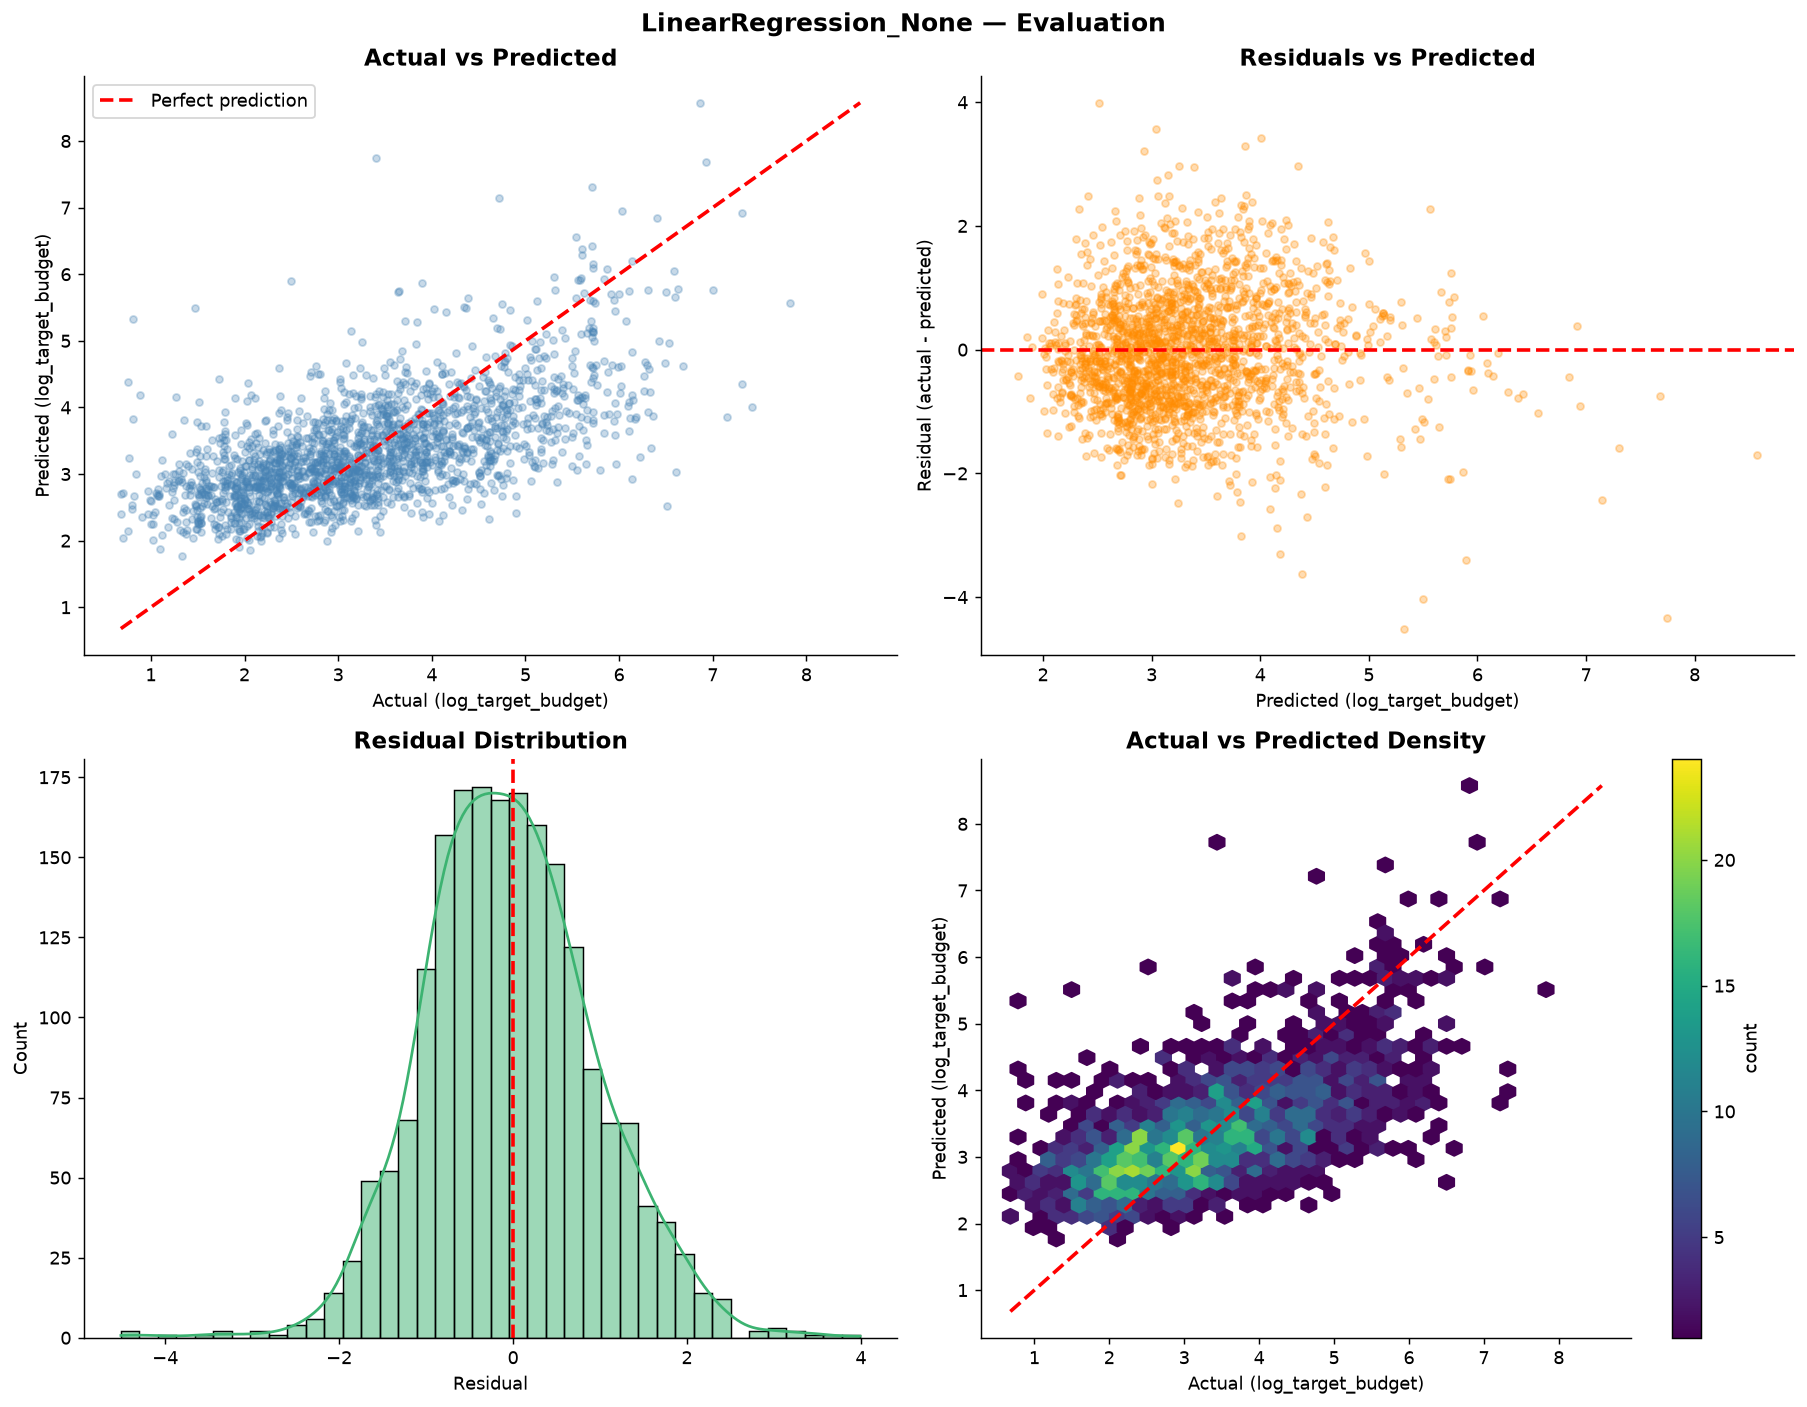

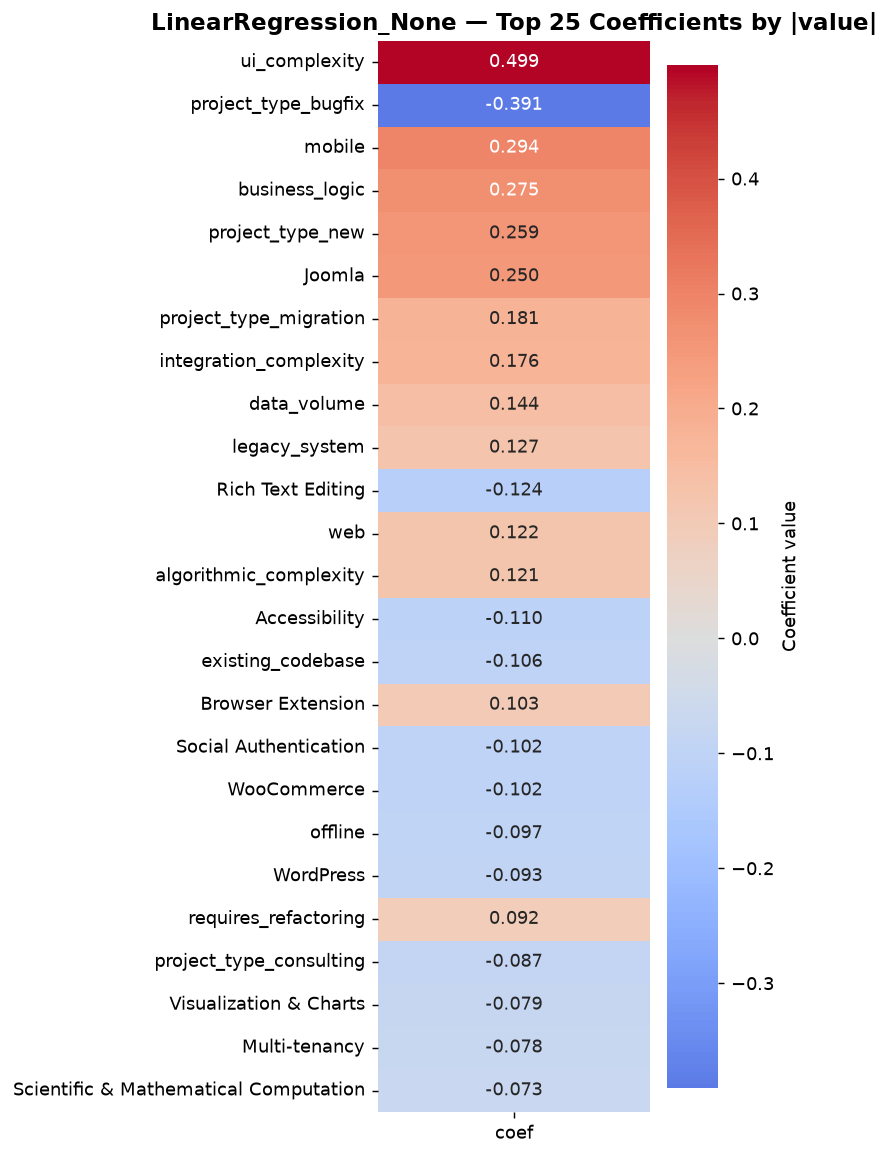

In [5]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Train + Evaluate Linear Regression
# ============================================================

def evaluate_linreg(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name,
    weight_mode="sqrt",   # none | log | sqrt | linear
):

    # --------------------------------------------------------
    # Sample weights (same logic as CatBoost version)
    # --------------------------------------------------------

    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = LinearRegression()

    model.fit(
        X_tr,
        y_tr,
        sample_weight=sample_weight,
    )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae_te = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Weight mode    : {weight_mode}")
    print(f"Train R²       : {r2_tr:.4f}")
    print(f"Test  R²       : {r2_te:.4f}")
    print(f"RMSE (log)     : {rmse_te:.4f}")
    print(f"MAE            : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------

    residuals = y_te - pred_te

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f"{name} — Evaluation", fontsize=14, fontweight="bold")

    # 1) Actual vs Predicted (log target)
    ax = axes[0, 0]
    ax.scatter(y_te, pred_te, alpha=0.3, s=15, color="steelblue")
    lims = [min(y_te.min(), pred_te.min()), max(y_te.max(), pred_te.max())]
    ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
    ax.set_xlabel("Actual (log_target_budget)")
    ax.set_ylabel("Predicted (log_target_budget)")
    ax.set_title("Actual vs Predicted")
    ax.legend()

    # 2) Residuals vs Predicted
    ax = axes[0, 1]
    ax.scatter(pred_te, residuals, alpha=0.3, s=15, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", lw=2)
    ax.set_xlabel("Predicted (log_target_budget)")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title("Residuals vs Predicted")

    # 3) Residual distribution
    ax = axes[1, 0]
    sns.histplot(residuals, bins=40, kde=True, ax=ax, color="mediumseagreen")
    ax.axvline(0, color="red", linestyle="--", lw=2)
    ax.set_xlabel("Residual")
    ax.set_title("Residual Distribution")

    # 4) Actual vs Predicted density heatmap (hexbin)
    ax = axes[1, 1]
    hb = ax.hexbin(y_te, pred_te, gridsize=35, cmap="viridis", mincnt=1)
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Actual (log_target_budget)")
    ax.set_ylabel("Predicted (log_target_budget)")
    ax.set_title("Actual vs Predicted Density")
    fig.colorbar(hb, ax=ax, label="count")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Coefficient heatmap (top N by |coef|)
    # --------------------------------------------------------

    if hasattr(X_tr, "columns"):
        coefs = pd.Series(model.coef_, index=X_tr.columns)
        top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index[:25])

        plt.figure(figsize=(6, 9))
        sns.heatmap(
            top_coefs.to_frame(name="coef"),
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            center=0,
            cbar_kws={"label": "Coefficient value"},
        )
        plt.title(f"{name} — Top 25 Coefficients by |value|")
        plt.tight_layout()
        plt.show()

    return {
        "model": model,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
    }


# ============================================================
# Train
# ============================================================

lin_none = evaluate_linreg(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "LinearRegression_None",
    weight_mode="none",
)

## Ridge and Lasso

In [6]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ============================================================
# Grid search Ridge / Lasso alpha on VALIDATION set
# ============================================================

def tune_linear_model(
    X_tr, y_tr,
    X_val, y_val,
    model_type="ridge",   # ridge | lasso
    alphas=None,
    weight_mode="sqrt",
):
    if alphas is None:
        # Wide log-spaced sweep — narrow it down once you see where the best lands
        alphas = np.logspace(-3, 3, 25)  # 0.001 to 1000

    # --------------------------------------------------------
    # Sample weights (same as before)
    # --------------------------------------------------------
    budget_train = np.expm1(y_tr)
    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    results = []

    for alpha in alphas:
        if model_type == "ridge":
            model = Ridge(alpha=alpha, random_state=42)
        elif model_type == "lasso":
            model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        else:
            raise ValueError("model_type must be 'ridge' or 'lasso'")

        model.fit(X_tr, y_tr, sample_weight=sample_weight)

        pred_val = model.predict(X_val)

        r2_val = r2_score(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        mae_val = mean_absolute_error(np.expm1(y_val), np.expm1(pred_val))

        n_nonzero = np.sum(model.coef_ != 0)  # interesting for Lasso — feature selection

        results.append({
            "alpha": alpha,
            "r2_val": r2_val,
            "rmse_val": rmse_val,
            "mae_val": mae_val,
            "n_nonzero_coefs": n_nonzero,
            "model": model,
        })

    results_df = pd.DataFrame(results).sort_values("r2_val", ascending=False).reset_index(drop=True)

    print(f"\n{'='*70}")
    print(f"{model_type.upper()} — Alpha sweep results (sorted by validation R²)")
    print(f"{'='*70}")
    print(results_df.drop(columns="model").to_string(index=False))

    best = results_df.iloc[0]
    print(f"\nBest alpha: {best['alpha']:.5f}  |  Val R²: {best['r2_val']:.4f}  |  Val MAE: {best['mae_val']:,.0f}")

    return results_df, best["model"], best["alpha"]


# ============================================================
# Run for both Ridge and Lasso
# ============================================================

ridge_results, best_ridge_model, best_ridge_alpha = tune_linear_model(
    X_tr, yB_tr,
    X_val, yB_val,
    model_type="ridge",
    weight_mode="none",
)

lasso_results, best_lasso_model, best_lasso_alpha = tune_linear_model(
    X_tr, yB_tr,
    X_val, yB_val,
    model_type="lasso",
    weight_mode="none",
)


RIDGE — Alpha sweep results (sorted by validation R²)
      alpha   r2_val  rmse_val   mae_val  n_nonzero_coefs
   0.001000 0.403125  0.983783 56.952431              110
   0.001778 0.403125  0.983783 56.952435              110
   0.003162 0.403125  0.983783 56.952443              110
   0.005623 0.403125  0.983783 56.952457              110
   0.010000 0.403125  0.983783 56.952481              110
   0.017783 0.403125  0.983783 56.952525              110
   0.031623 0.403125  0.983783 56.952602              110
   0.056234 0.403125  0.983783 56.952740              110
   0.100000 0.403125  0.983783 56.952984              110
   0.177828 0.403125  0.983783 56.953420              110
   0.316228 0.403125  0.983783 56.954192              110
   0.562341 0.403124  0.983784 56.955564              110
   1.000000 0.403123  0.983785 56.957996              110
   1.778279 0.403121  0.983787 56.962295              110
   3.162278 0.403117  0.983790 56.969867              110
   5.623413 0.403

In [7]:
# ============================================================
# Final evaluation — TEST set, touched once
# ============================================================

final_model = best_ridge_model if ridge_results.iloc[0]["r2_val"] > lasso_results.iloc[0]["r2_val"] else best_lasso_model
final_name = "Ridge" if final_model is best_ridge_model else "Lasso"

pred_te = final_model.predict(X_te)

r2_te = r2_score(yB_te, pred_te)
mae_te = mean_absolute_error(np.expm1(yB_te), np.expm1(pred_te))
rmse_te = np.sqrt(mean_squared_error(yB_te, pred_te))

print(f"\nFinal model: {final_name}")
print(f"Test R²   : {r2_te:.4f}")
print(f"Test RMSE : {rmse_te:.4f}")
print(f"Test MAE  : {mae_te:,.0f}")


Final model: Lasso
Test R²   : 0.4000
Test RMSE : 0.9746
Test MAE  : 50


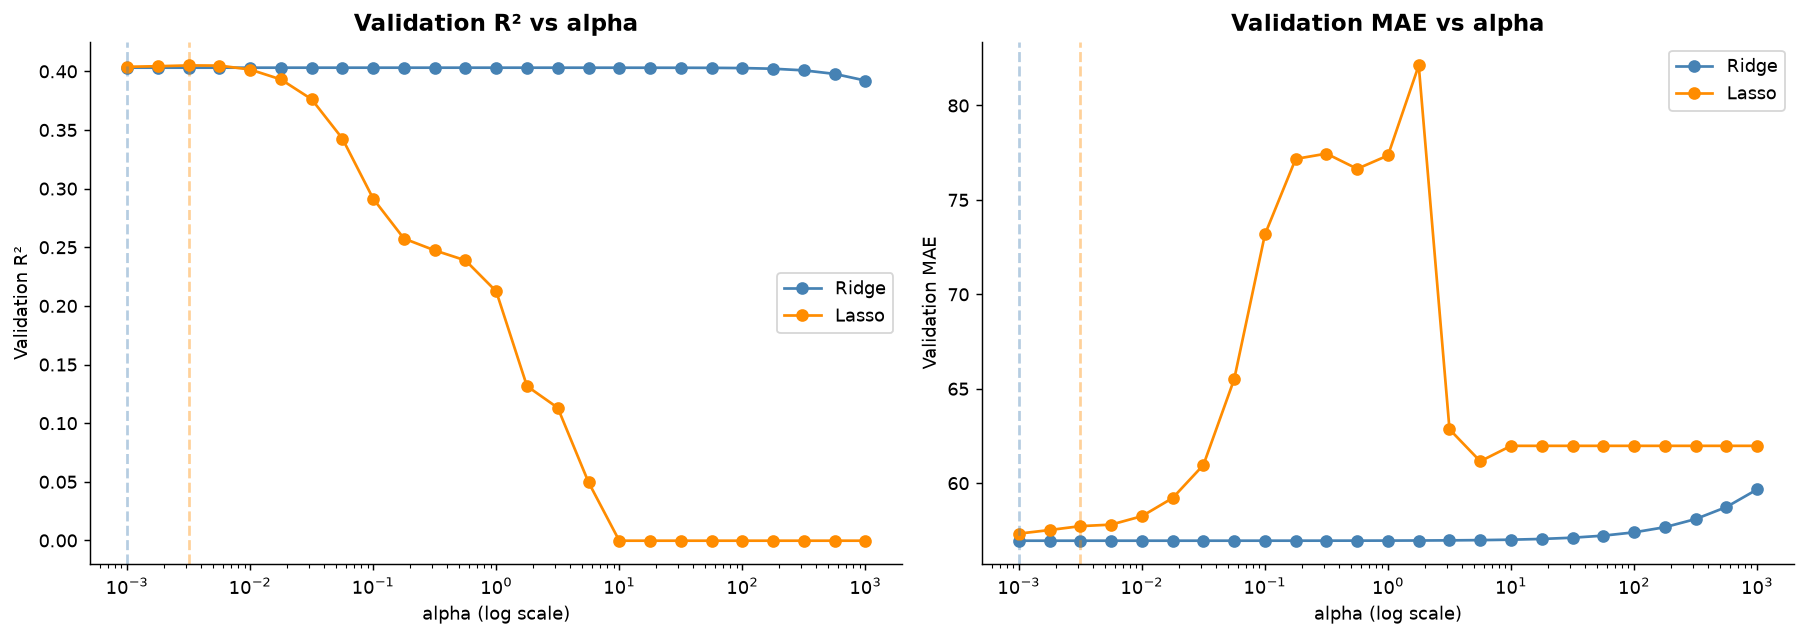

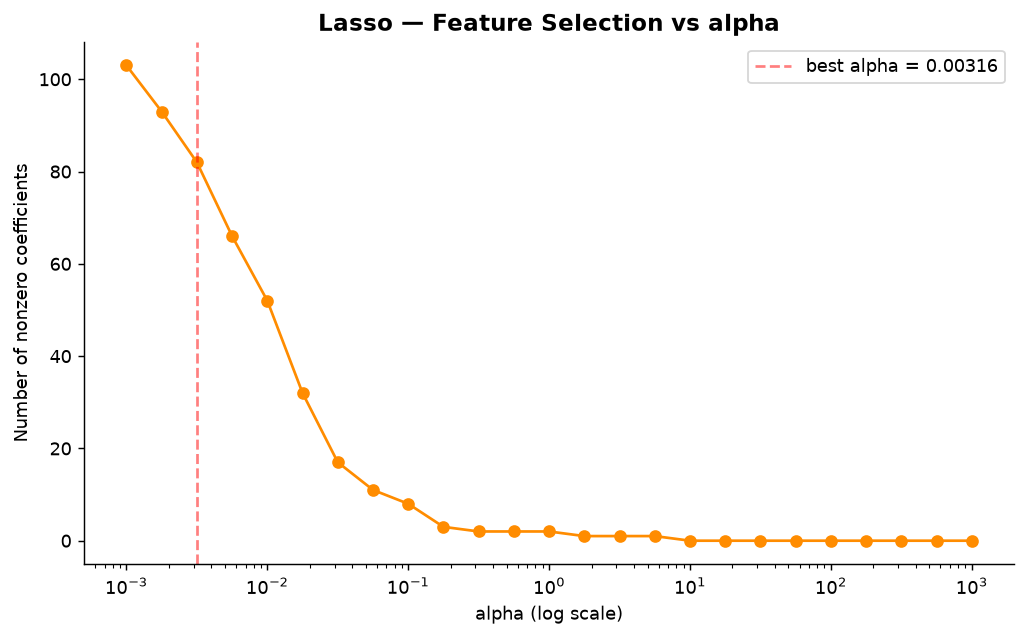

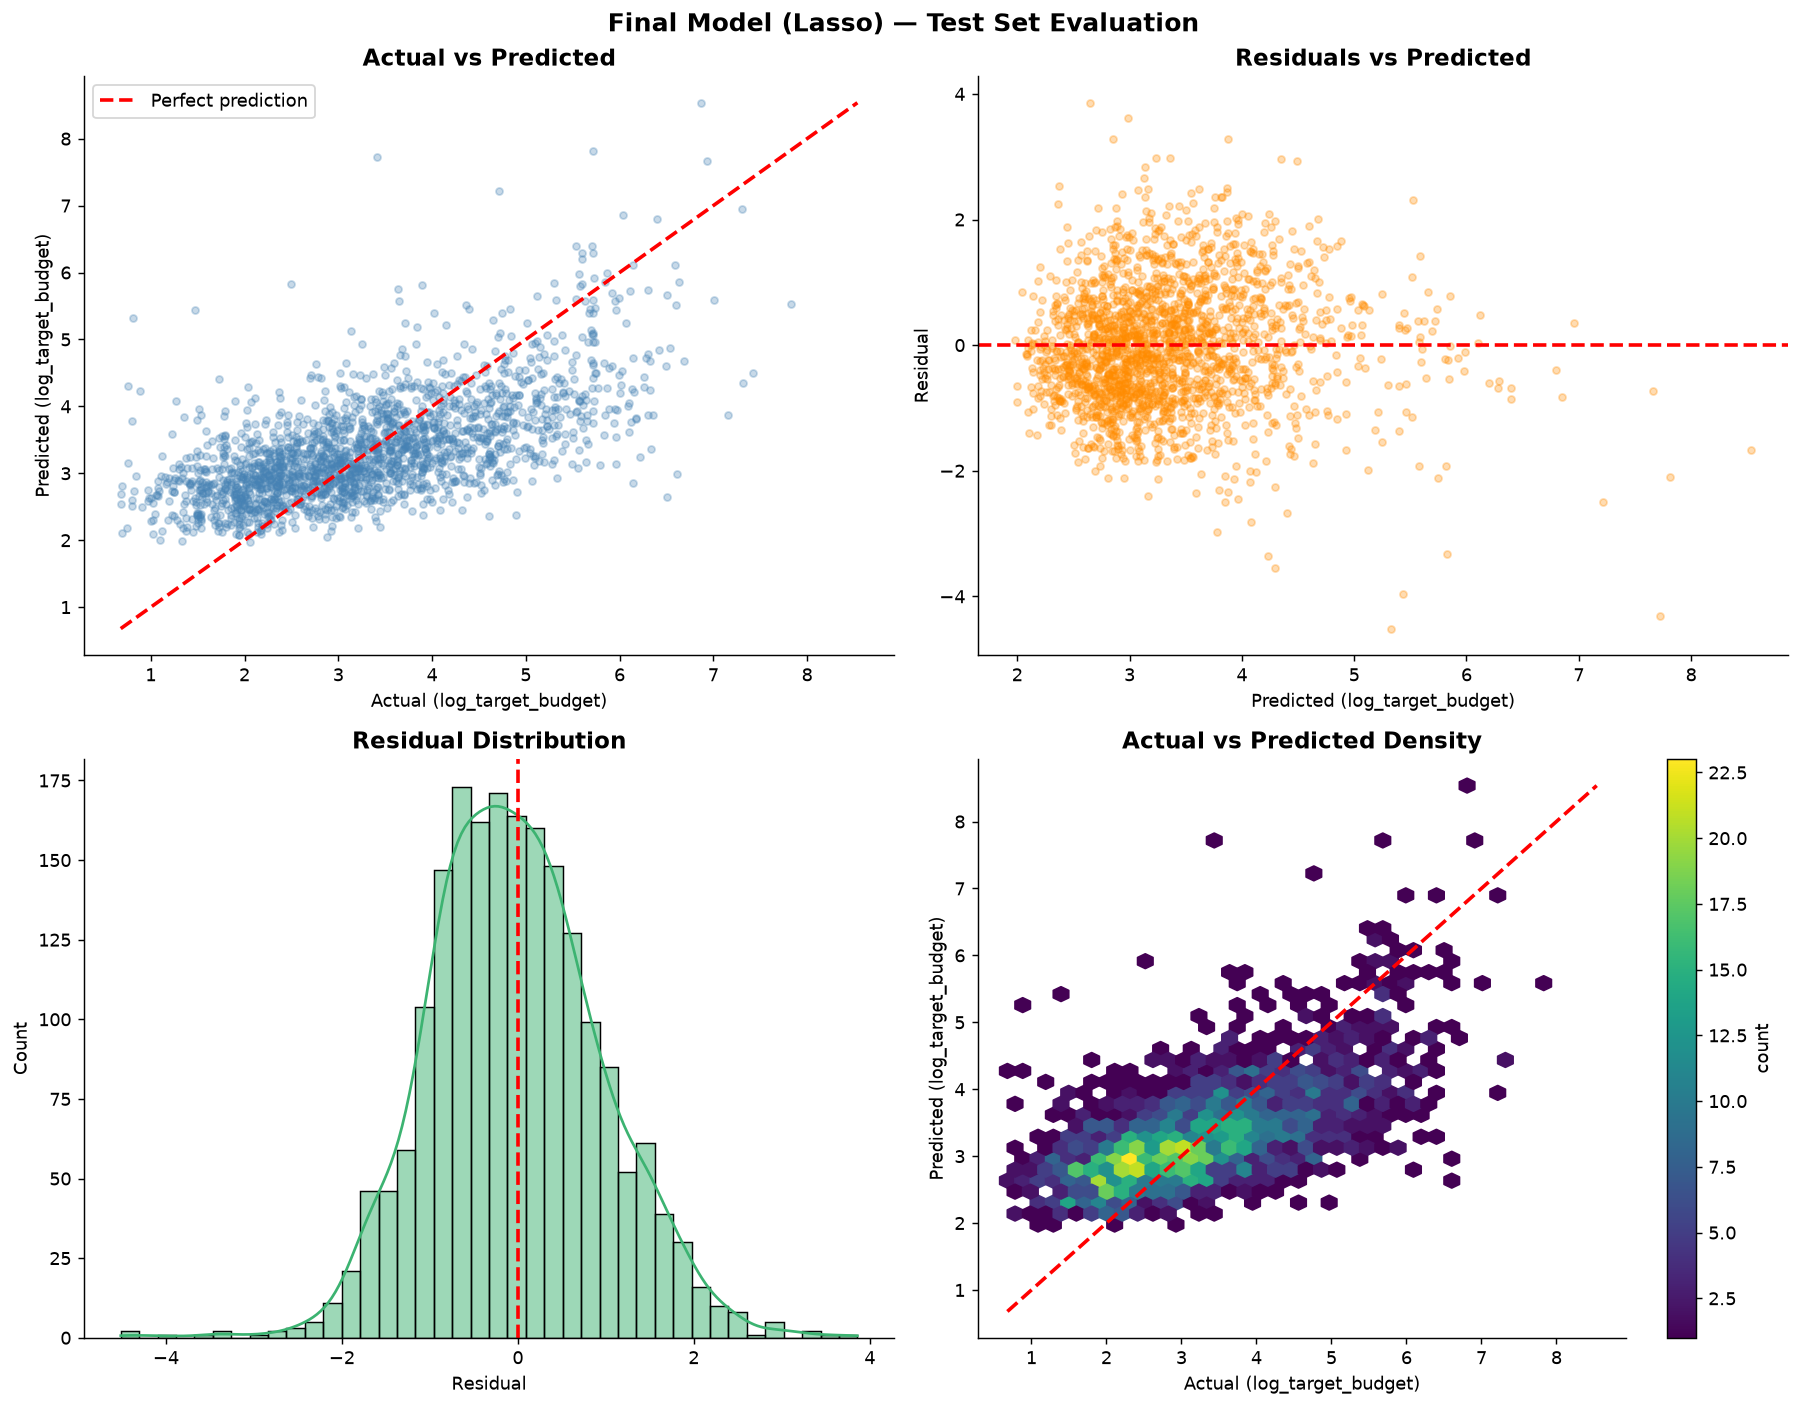

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1) Alpha sweep — R² and MAE vs alpha (Ridge + Lasso)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for results_df, label, color in [
    (ridge_results, "Ridge", "steelblue"),
    (lasso_results, "Lasso", "darkorange"),
]:
    sorted_by_alpha = results_df.sort_values("alpha")

    axes[0].plot(
        sorted_by_alpha["alpha"], sorted_by_alpha["r2_val"],
        marker="o", label=label, color=color,
    )
    axes[1].plot(
        sorted_by_alpha["alpha"], sorted_by_alpha["mae_val"],
        marker="o", label=label, color=color,
    )

axes[0].set_xscale("log")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("Validation R²")
axes[0].set_title("Validation R² vs alpha")
axes[0].legend()
axes[0].axvline(best_ridge_alpha, color="steelblue", linestyle="--", alpha=0.4)
axes[0].axvline(best_lasso_alpha, color="darkorange", linestyle="--", alpha=0.4)

axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("Validation MAE")
axes[1].set_title("Validation MAE vs alpha")
axes[1].legend()
axes[1].axvline(best_ridge_alpha, color="steelblue", linestyle="--", alpha=0.4)
axes[1].axvline(best_lasso_alpha, color="darkorange", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# 2) Lasso — number of nonzero coefficients vs alpha
#    (shows feature selection behavior — useful given 164 cols)
# ============================================================

lasso_sorted = lasso_results.sort_values("alpha")

plt.figure(figsize=(8, 5))
plt.plot(lasso_sorted["alpha"], lasso_sorted["n_nonzero_coefs"], marker="o", color="darkorange")
plt.axvline(best_lasso_alpha, color="red", linestyle="--", alpha=0.5, label=f"best alpha = {best_lasso_alpha:.5f}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Number of nonzero coefficients")
plt.title("Lasso — Feature Selection vs alpha")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3) Final model diagnostics on TEST set
# ============================================================

residuals_te = yB_te - pred_te

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f"Final Model ({final_name}) — Test Set Evaluation", fontsize=14, fontweight="bold")

# Actual vs Predicted
ax = axes[0, 0]
ax.scatter(yB_te, pred_te, alpha=0.3, s=15, color="steelblue")
lims = [min(yB_te.min(), pred_te.min()), max(yB_te.max(), pred_te.max())]
ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
ax.set_xlabel("Actual (log_target_budget)")
ax.set_ylabel("Predicted (log_target_budget)")
ax.set_title("Actual vs Predicted")
ax.legend()

# Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(pred_te, residuals_te, alpha=0.3, s=15, color="darkorange")
ax.axhline(0, color="red", linestyle="--", lw=2)
ax.set_xlabel("Predicted (log_target_budget)")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs Predicted")

# Residual distribution
ax = axes[1, 0]
sns.histplot(residuals_te, bins=40, kde=True, ax=ax, color="mediumseagreen")
ax.axvline(0, color="red", linestyle="--", lw=2)
ax.set_xlabel("Residual")
ax.set_title("Residual Distribution")

# Density heatmap
ax = axes[1, 1]
hb = ax.hexbin(yB_te, pred_te, gridsize=35, cmap="viridis", mincnt=1)
ax.plot(lims, lims, "r--", lw=2)
ax.set_xlabel("Actual (log_target_budget)")
ax.set_ylabel("Predicted (log_target_budget)")
ax.set_title("Actual vs Predicted Density")
fig.colorbar(hb, ax=ax, label="count")

plt.tight_layout()
plt.show()

## PCA plotting

PC1 explains 7.52% of variance
PC2 explains 5.00% of variance
Combined: 12.53%


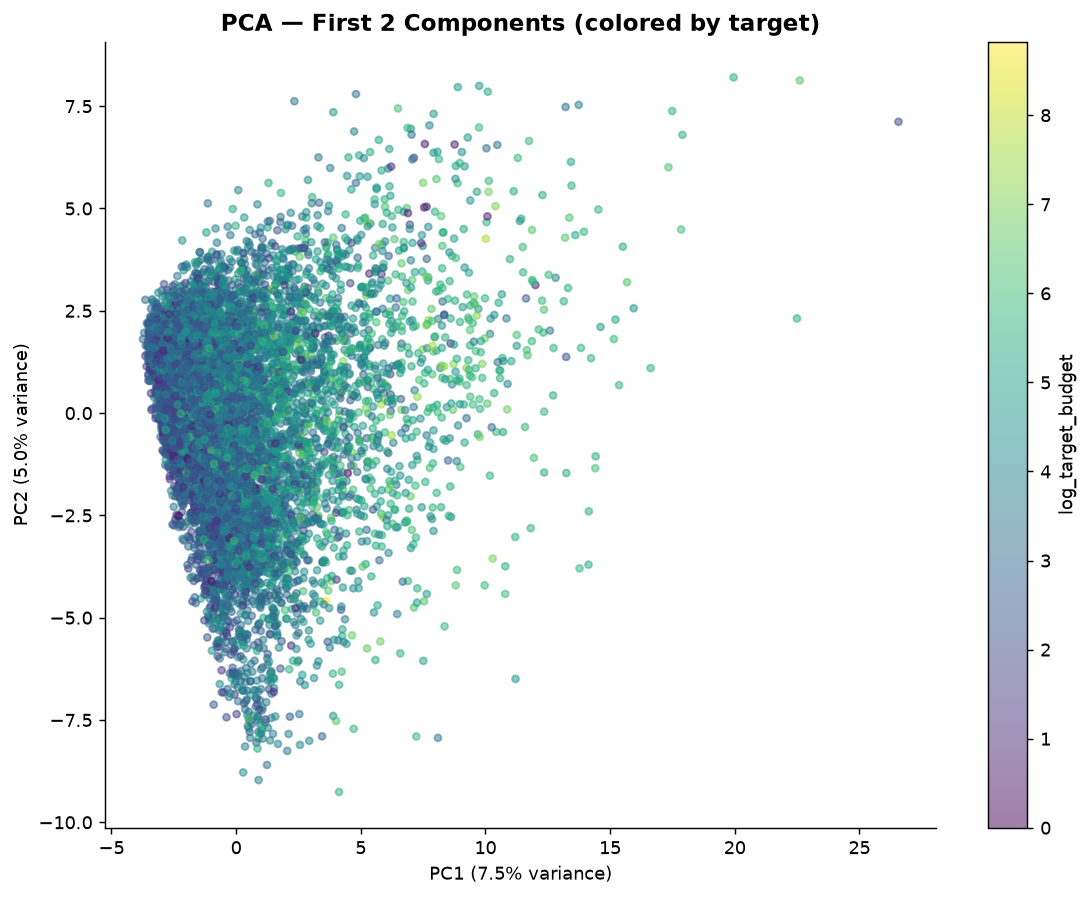

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ============================================================
# PCA on training features
# ============================================================

# Standardize first — PCA is scale-sensitive and your features
# mix one-hot columns with raw-scale numeric ones
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tr)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]:.2%} of variance")
print(f"PC2 explains {explained[1]:.2%} of variance")
print(f"Combined: {explained.sum():.2%}")

# --------------------------------------------------------
# Plot — colored by target (log_target_budget)
# --------------------------------------------------------

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=yB_tr,
    cmap="viridis",
    alpha=0.5,
    s=15,
)
plt.colorbar(sc, label="log_target_budget")
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.title("PCA — First 2 Components (colored by target)")
plt.tight_layout()
plt.show()

## Cat Boost With Validation

In [18]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import itertools

# ============================================================
# Train + Evaluate CatBoost (fixed to use passed-in val set)
# ============================================================

def evaluate_catboost(
    X_tr, y_tr,
    X_val, y_val,
    X_te, y_te,
    name,
    weight_mode="sqrt",
    depth=6,
    l2_leaf_reg=10,
    learning_rate=0.02,
    bagging_temperature=1,
    verbose=0,
):
    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        bootstrap_type="Bayesian",
        bagging_temperature=bagging_temperature,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=200,
        verbose=verbose,
    )

    model.fit(
        X_tr, y_tr,
        sample_weight=sample_weight,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    pred_tr = model.predict(X_tr)
    pred_val = model.predict(X_val)
    pred_te = model.predict(X_te)

    r2_tr = r2_score(y_tr, pred_tr)
    r2_val = r2_score(y_val, pred_val)
    r2_te = r2_score(y_te, pred_te)

    mae_val = mean_absolute_error(np.expm1(y_val), np.expm1(pred_val))
    mae_te = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))

    return {
        "model": model,
        "best_iteration": model.get_best_iteration(),
        "pred_val": pred_val,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_val": r2_val,
        "r2_test": r2_te,
        "mae_val": mae_val,
        "mae_test": mae_te,
        "rmse_test": rmse_te,
    }


# ============================================================
# Hyperparameter grid search — evaluated on VALIDATION
# ============================================================

def tune_catboost(
    X_tr, y_tr,
    X_val, y_val,
    weight_mode="none",
    depths=(4,5),
    l2_leaf_regs=(3,1),
    learning_rates=(0.01,1 ),
    bagging_temperatures=(0,1),
):
    grid = list(itertools.product(depths, l2_leaf_regs, learning_rates, bagging_temperatures))
    print(f"Sweeping {len(grid)} combinations...")

    results = []

    for i, (depth, l2, lr, bt) in enumerate(grid, 1):
        res = evaluate_catboost(
            X_tr, y_tr,
            X_val, y_val,
            X_val, y_val,   # test slot unused here — just reusing val for the call
            name=f"combo_{i}",
            weight_mode=weight_mode,
            depth=depth,
            l2_leaf_reg=l2,
            learning_rate=lr,
            bagging_temperature=bt,
            verbose=0,
        )

        results.append({
            "depth": depth,
            "l2_leaf_reg": l2,
            "learning_rate": lr,
            "bagging_temperature": bt,
            "best_iteration": res["best_iteration"],
            "r2_val": res["r2_val"],
            "mae_val": res["mae_val"],
        })

        print(f"[{i}/{len(grid)}] depth={depth} l2={l2} lr={lr} bt={bt} "
              f"-> val R²={res['r2_val']:.4f}, val MAE={res['mae_val']:,.0f}")

    results_df = pd.DataFrame(results).sort_values("r2_val", ascending=False).reset_index(drop=True)

    print(f"\n{'='*70}")
    print("Top 10 combinations by validation R²")
    print(f"{'='*70}")
    print(results_df.head(10).to_string(index=False))

    best = results_df.iloc[0]
    print(f"\nBest params: depth={best['depth']}, l2_leaf_reg={best['l2_leaf_reg']}, "
          f"learning_rate={best['learning_rate']}, bagging_temperature={best['bagging_temperature']}")
    print(f"Best val R²: {best['r2_val']:.4f}")

    return results_df, best


# ============================================================
# Run sweep
# ============================================================

cat_results, best_cat_params = tune_catboost(
    X_tr, yB_tr,
    X_val, yB_val,
    weight_mode="none",
)

Sweeping 16 combinations...
[1/16] depth=4 l2=3 lr=0.01 bt=0 -> val R²=0.4873, val MAE=47
[2/16] depth=4 l2=3 lr=0.01 bt=1 -> val R²=0.4894, val MAE=48
[3/16] depth=4 l2=3 lr=1 bt=0 -> val R²=0.4642, val MAE=49
[4/16] depth=4 l2=3 lr=1 bt=1 -> val R²=0.4555, val MAE=49
[5/16] depth=4 l2=1 lr=0.01 bt=0 -> val R²=0.4879, val MAE=48
[6/16] depth=4 l2=1 lr=0.01 bt=1 -> val R²=0.4898, val MAE=48
[7/16] depth=4 l2=1 lr=1 bt=0 -> val R²=0.4604, val MAE=49
[8/16] depth=4 l2=1 lr=1 bt=1 -> val R²=0.4442, val MAE=49
[9/16] depth=5 l2=3 lr=0.01 bt=0 -> val R²=0.4903, val MAE=48
[10/16] depth=5 l2=3 lr=0.01 bt=1 -> val R²=0.4905, val MAE=48
[11/16] depth=5 l2=3 lr=1 bt=0 -> val R²=0.4698, val MAE=50
[12/16] depth=5 l2=3 lr=1 bt=1 -> val R²=0.4542, val MAE=50
[13/16] depth=5 l2=1 lr=0.01 bt=0 -> val R²=0.4901, val MAE=48
[14/16] depth=5 l2=1 lr=0.01 bt=1 -> val R²=0.4907, val MAE=48
[15/16] depth=5 l2=1 lr=1 bt=0 -> val R²=0.4617, val MAE=50
[16/16] depth=5 l2=1 lr=1 bt=1 -> val R²=0.4500, val MAE=

In [19]:
# ============================================================
# Final CatBoost — best params, evaluated on TEST once
# ============================================================

cat_final = evaluate_catboost(
    X_tr, yB_tr,
    X_val, yB_val,
    X_te, yB_te,
    name="CatBoost_Final",
    weight_mode="none",
    depth=int(best_cat_params["depth"]),
    l2_leaf_reg=best_cat_params["l2_leaf_reg"],
    learning_rate=best_cat_params["learning_rate"],
    bagging_temperature=best_cat_params["bagging_temperature"],
    verbose=100,
)

print(f"\nFinal Test R²  : {cat_final['r2_test']:.4f}")
print(f"Final Test MAE : {cat_final['mae_test']:,.0f}")
print(f"Final Test RMSE: {cat_final['rmse_test']:.4f}")

0:	learn: 1.2508369	test: 1.2689058	best: 1.2689058 (0)	total: 4.76ms	remaining: 23.8s
100:	learn: 1.0099409	test: 1.0265686	best: 1.0265686 (100)	total: 509ms	remaining: 24.7s
200:	learn: 0.9488751	test: 0.9633575	best: 0.9633575 (200)	total: 918ms	remaining: 21.9s
300:	learn: 0.9271366	test: 0.9430324	best: 0.9430324 (300)	total: 1.39s	remaining: 21.6s
400:	learn: 0.9160483	test: 0.9345456	best: 0.9345456 (400)	total: 1.75s	remaining: 20s
500:	learn: 0.9085622	test: 0.9301872	best: 0.9301872 (500)	total: 2.08s	remaining: 18.7s
600:	learn: 0.9027345	test: 0.9274408	best: 0.9274408 (600)	total: 2.43s	remaining: 17.8s
700:	learn: 0.8979077	test: 0.9254661	best: 0.9254661 (700)	total: 2.79s	remaining: 17.1s
800:	learn: 0.8934549	test: 0.9238151	best: 0.9238151 (800)	total: 3.14s	remaining: 16.5s
900:	learn: 0.8890049	test: 0.9223035	best: 0.9222941 (897)	total: 3.5s	remaining: 15.9s
1000:	learn: 0.8844770	test: 0.9208643	best: 0.9208643 (1000)	total: 3.88s	remaining: 15.5s
1100:	learn: 0

## 5 · Train CatBoost model

In [20]:
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

# ============================================================
# Train + Evaluate CatBoost
# ============================================================

def evaluate_catboost(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name,
    weight_mode="sqrt",   # none | log | sqrt | linear
):

    # --------------------------------------------------------
    # Sample weights
    # --------------------------------------------------------

    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None

    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)

    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)

    elif weight_mode == "linear":
        sample_weight = budget_train

    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = CatBoostRegressor(

        iterations=5000,
        learning_rate=0.02,
        depth=6,

        l2_leaf_reg=10,

        bootstrap_type="Bayesian",
        bagging_temperature=1,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,

        early_stopping_rounds=200,

        verbose=100,
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(

        X_tr,
        y_tr,

        sample_weight=sample_weight,

        eval_set=(X_val, yB_val),

        use_best_model=True,

    )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae_te = mean_absolute_error(
        np.expm1(y_te),
        np.expm1(pred_te),
    )

    rmse_te = np.sqrt(
        mean_squared_error(
            y_te,
            pred_te,
        )
    )

    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Weight mode    : {weight_mode}")
    print(f"Best iteration : {model.get_best_iteration()}")
    print(f"Train R²       : {r2_tr:.4f}")
    print(f"Test  R²       : {r2_te:.4f}")
    print(f"RMSE (log)     : {rmse_te:.4f}")
    print(f"MAE            : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    return {
        "model": model,
        "history": None,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
    }


# ============================================================
# Train
# ============================================================

cat_none = evaluate_catboost(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "CatBoost_None",
    weight_mode="none",
)


0:	learn: 1.2466182	test: 1.2647741	best: 1.2647741 (0)	total: 3.89ms	remaining: 19.5s
100:	learn: 0.9456240	test: 0.9627237	best: 0.9627237 (100)	total: 519ms	remaining: 25.1s
200:	learn: 0.9132517	test: 0.9334288	best: 0.9334288 (200)	total: 1.1s	remaining: 26.3s
300:	learn: 0.9016027	test: 0.9265857	best: 0.9265857 (300)	total: 1.71s	remaining: 26.7s
400:	learn: 0.8936760	test: 0.9232057	best: 0.9232057 (400)	total: 2.26s	remaining: 26s
500:	learn: 0.8857948	test: 0.9200982	best: 0.9200871 (499)	total: 2.8s	remaining: 25.2s
600:	learn: 0.8774606	test: 0.9173869	best: 0.9173869 (600)	total: 3.27s	remaining: 24s
700:	learn: 0.8713190	test: 0.9159378	best: 0.9159378 (700)	total: 3.85s	remaining: 23.6s
800:	learn: 0.8652379	test: 0.9147194	best: 0.9147180 (799)	total: 4.27s	remaining: 22.4s
900:	learn: 0.8598756	test: 0.9133910	best: 0.9133767 (898)	total: 4.79s	remaining: 21.8s
1000:	learn: 0.8545740	test: 0.9126650	best: 0.9126650 (1000)	total: 5.38s	remaining: 21.5s
1100:	learn: 0.84

## Save Model

In [21]:
model = cat_none["model"]


# Save the trained model itself
model.save_model("catboost_price_model.cbm")

project_type_dummy_cols = [c for c in ALL_FEATURES if c.startswith("project_type_")]

feature_schema = {
    "columns": ALL_FEATURES,                      # exact order model was trained on
    "target_transform": "log1p",
    "ordinal_cols": ordinal_cols_present,          # which ordinal cols actually survived NON_FEATURE
    "enum_order": {c: ENUM_ORDER[c] for c in ordinal_cols_present},  # index = encoded value
    "project_type_prefix": "project_type_",
    "project_type_dummy_cols": project_type_dummy_cols,  # exact categories seen in training data
}
with open("catboost_price_model_schema.json", "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

print(f"Saved model with {len(ALL_FEATURES)} features")
print(f"Ordinal cols in this model: {ordinal_cols_present}")
print(f"project_type dummies in this model: {project_type_dummy_cols}")



Saved model with 110 features
Ordinal cols in this model: ['ai_level', 'business_logic', 'data_volume', 'integration_complexity', 'ui_complexity', 'algorithmic_complexity']
project_type dummies in this model: ['project_type_bugfix', 'project_type_consulting', 'project_type_maintenance', 'project_type_migration', 'project_type_new', 'project_type_optimization', 'project_type_testing']


## 6 · Deep learning approach (feed-forward neural net)
Same features, same log-transformed targets — but a small dense neural network instead of trees. Neural nets need scaled inputs (trees don't), so we standardize features first.

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

# ============================================================
# Scale features
# ============================================================
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

print(X_tr_scaled.shape)
print(X_te_scaled.shape)

# ============================================================
# Build model
# ============================================================
def build_mlp(input_dim, name):
    l2 = regularizers.l2(1e-5)  # mild — drop this first if train R² stays low

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(128, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(64, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.10),

        layers.Dense(32, activation="gelu", kernel_regularizer=l2),
        layers.Dense(1),
    ], name=name)

    optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(delta=1.0),  # keep 1.0 for now; try 0.5 as a separate run if outliers are a known issue
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

# ============================================================
# Callbacks
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=1,
)

# ============================================================
# Train + Evaluate
# ============================================================
def evaluate_dl(X_tr_s, y_tr, X_te_s, y_te, name, epochs=300, batch_size=64):
    model = build_mlp(X_tr_s.shape[1], name)

    history = model.fit(
        X_tr_s, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1,          # <-- per-epoch progress bar
        shuffle=True,
    )

    pred_tr = model.predict(X_tr_s, verbose=0).flatten()
    pred_te = model.predict(X_te_s, verbose=0).flatten()

    mae_te  = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    n_epochs = len(history.history["loss"])

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Training epochs : {n_epochs}")
    print(f"Train R²        : {r2_tr:.4f}")
    print(f"Test  R²        : {r2_te:.4f}")
    print(f"RMSE (log)      : {rmse_te:.4f}")
    print(f"MAE             : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    return {
        "model": model, "history": history, "pred_test": pred_te,
        "r2_train": r2_tr, "r2_test": r2_te, "mae_test": mae_te,
    }

# ============================================================
# Train
# ============================================================
print("=== Deep Learning Budget Model ===")

dl_budget = evaluate_dl(
    X_tr_scaled, yB_tr, X_te_scaled, yB_te, "MLP_AdamW_Huber",
)

(9173, 110)
(1966, 110)
=== Deep Learning Budget Model ===
Epoch 1/300
122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.4984 - mae: 1.9398 - rmse: 2.4012 - val_loss: 1.0569 - val_mae: 1.4855 - val_rmse: 1.8311 - learning_rate: 3.0000e-04
Epoch 2/300
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6443 - mae: 1.0379 - rmse: 1.3239 - val_loss: 0.5366 - val_mae: 0.9125 - val_rmse: 1.2026 - learning_rate: 3.0000e-04
Epoch 3/300
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5347 - mae: 0.9129 - rmse: 1.1744 - val_loss: 0.4930 - val_mae: 0.8656 - val_rmse: 1.1340 - learning_rate: 3.0000e-04
Epoch 4/300
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4994 - mae: 0.8770 - rmse: 1.1173 - val_loss: 0.4768 - val_mae: 0.8480 - val_rmse: 1.1060 - learning_rate: 3.0000e-04
Epoch 5/300
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4706 - mae: 0.8423 - rmse: 1.0793 - val_loss: 0.4715 - val_mae: 0.8409 - val_rmse: 1.1022 - learning_rate: 3.0000e-04
Epoch 6/300
122/122 ━━━━━━━━━━━━━━━━

## 7a Training Curve

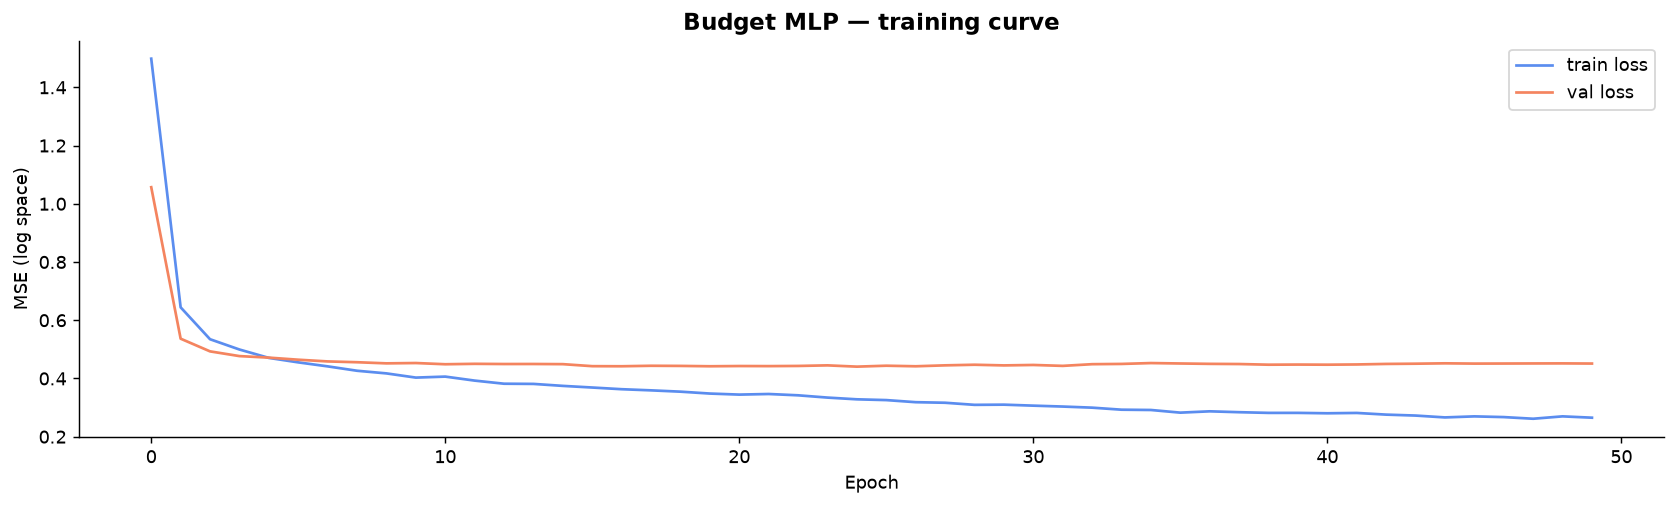

In [23]:
# Training curves — loss over epochs, useful for spotting over/underfitting
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
for ax, res, title in [
    (axes, dl_budget,   'Budget MLP — training curve'),
]:
    h = res['history'].history
    ax.plot(h['loss'], label='train loss', color=ACCENT)
    ax.plot(h['val_loss'], label='val loss', color=ACCENT2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log space)')
    ax.legend()
plt.tight_layout(); plt.show()


## 7b top projects with max and min errors

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Actual vs Predicted comparison table
# ============================================================

actual_usd    = np.expm1(yB_te)
predicted_usd = np.expm1(dl_budget['pred_test'])

comparison = pd.DataFrame({
    'project_id': df.loc[X_te.index, 'project_id'].values,   # adjust `df` to whatever your source frame is named
    'actual': actual_usd,
    'predicted': predicted_usd,
}, index=X_te.index)

comparison['abs_error']   = (comparison['actual'] - comparison['predicted']).abs()
comparison['pct_error']   = comparison['abs_error'] / comparison['actual'] * 100

comparison_sorted_worst = comparison.sort_values('pct_error', ascending=False)
comparison_sorted_best  = comparison.sort_values('pct_error', ascending=True)

print("=== Worst 15 predictions (highest % error) ===")
print(comparison_sorted_worst.head(15).round(2).to_string())

print()
print("=== Best 15 predictions (lowest % error) ===")
print(comparison_sorted_best.head(15).round(2).to_string())

print()
print(f"Median % error : {comparison['pct_error'].median():.2f}%")
print(f"Mean % error   : {comparison['pct_error'].mean():.2f}%")

# ============================================================
# Actual vs Predicted scatter chart with error-band lines
# ============================================================

# fig, ax = plt.subplots(figsize=(8, 8))

# ax.scatter(comparison['predicted'], comparison['actual'],
#            alpha=0.4, s=20, color='steelblue', label='Predictions')

# lims = [0, max(comparison['actual'].max(), comparison['predicted'].max()) * 1.05]
# x_line = np.linspace(lims[0], lims[1], 200)

# # actual = predicted (perfect prediction line)
# ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')

# # tolerance bands: actual within ±p% of predicted
# for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
#     ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
#              label=f'±{int(pct*100)}%')
#     ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)

# ax.set_xlim(lims)
# ax.set_ylim(lims)
# ax.set_xlabel('Predicted Price ($)')
# ax.set_ylabel('Actual Price ($)')
# ax.set_title('Actual vs Predicted Price')
# ax.legend(loc='upper left')
# ax.set_aspect('equal', adjustable='box')

# plt.tight_layout()
# plt.show()

=== Worst 15 predictions (highest % error) ===
                                 project_id  actual   predicted  abs_error  pct_error
1984   91e6e8fc-f0b3-4d33-92c1-6341a190e122    1.13   86.080002      84.95    7501.86
2704   919f33d1-6941-4d8a-a944-f8a444c42bb1    1.26   89.260002      88.00    7011.44
19     da70c9d3-f1ef-42f2-974e-3e56b48b7c16   11.14  685.979980     674.84    6058.90
2701   1178c645-8a04-49c0-a87e-50fa13421c05    1.41   82.379997      80.97    5742.85
9331   e4edaa86-dd9c-4ebe-92ac-1d8dd4ee83e9    3.35  139.009995     135.66    4047.59
2714   f7ad99aa-a7c7-4df6-bb68-280b7e3e94db    1.24   41.549999      40.32    3262.42
247    48be2b80-50cc-4e44-86ed-9b092ce437a0   29.20  851.400024     822.20    2815.92
3326   313a6c42-2371-42a4-9d0a-551d68359924    2.87   78.470001      75.60    2631.47
7449   27779d46-112b-4e23-9995-64938cad1f2d    4.64  101.760002      97.12    2094.86
9045   0c2fb347-f51e-47f7-b91f-2fda8e234d83    5.68  123.699997     118.02    2077.85
59     

## 7c heat map of project prediction distribuition

Dropped 751 rows (38.2%) above $50


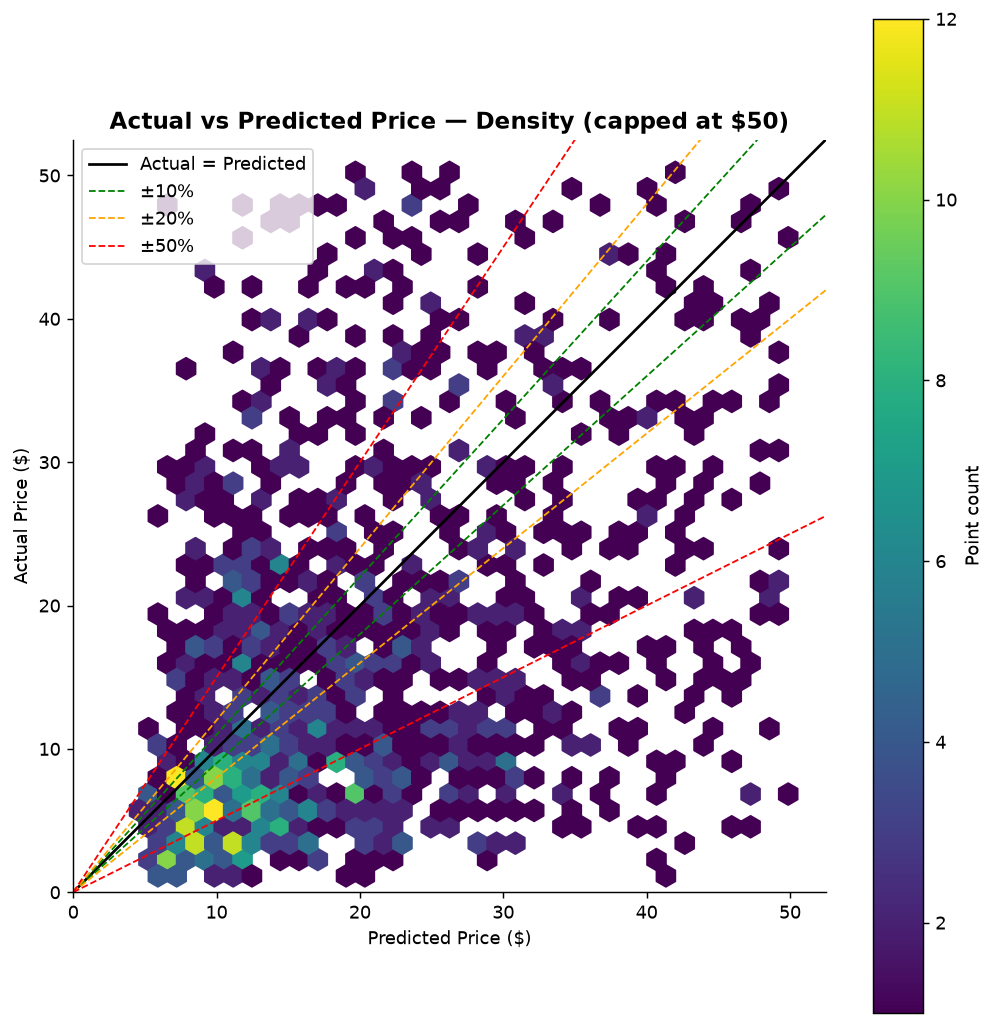

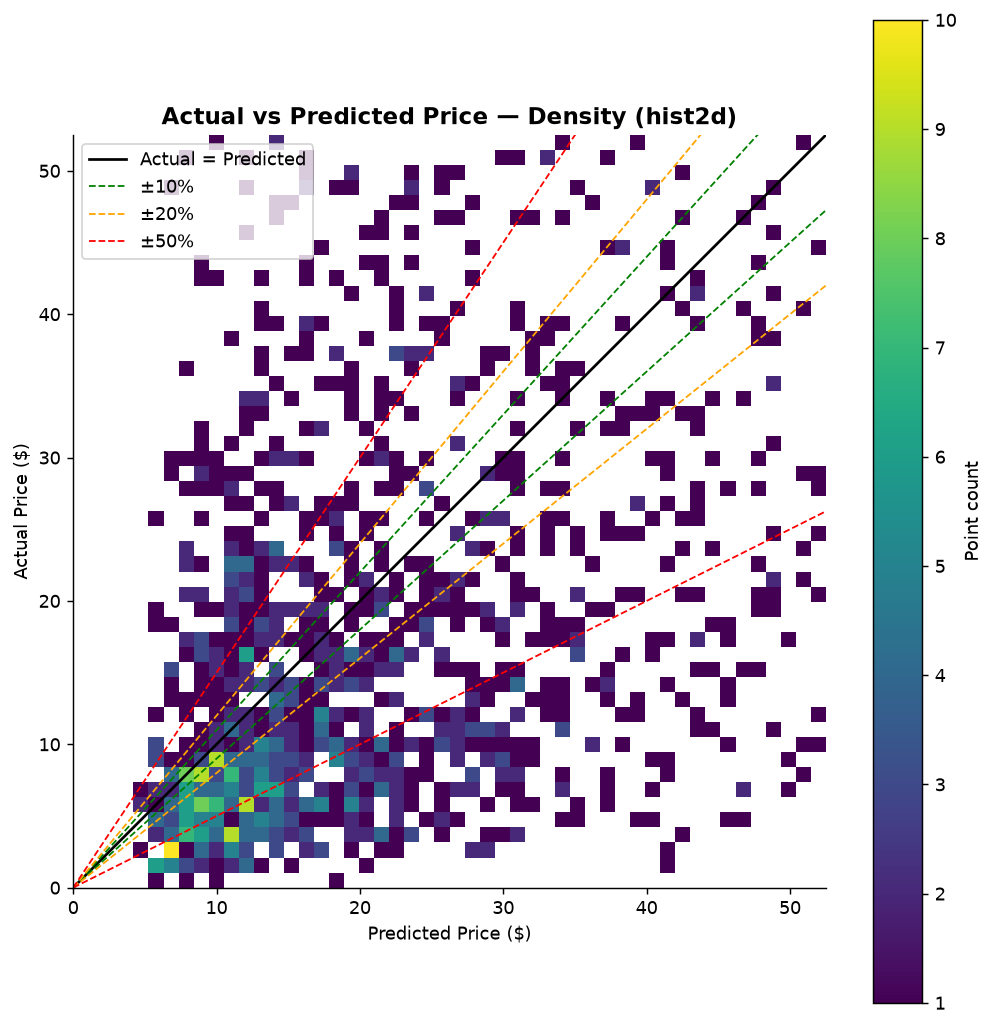

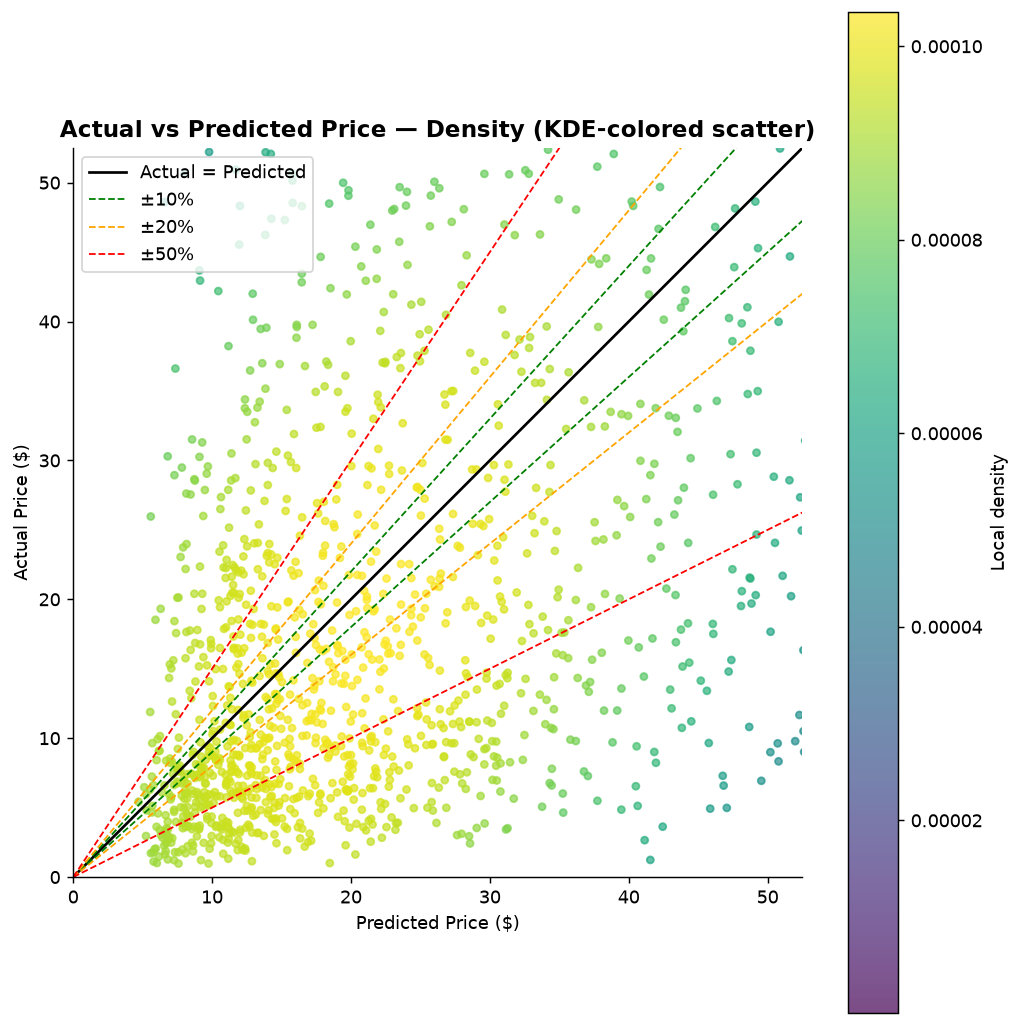

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

# ============================================================
# Set your cap here
# ============================================================
MAX_PRICE = 50   # adjust this — try comparison['actual'].quantile(0.95) to auto-pick a reasonable cutoff

plot_data = comparison[
    (comparison['actual'] <= MAX_PRICE) &
    (comparison['predicted'] <= MAX_PRICE)
]

n_dropped = len(comparison) - len(plot_data)
print(f"Dropped {n_dropped} rows ({n_dropped/len(comparison):.1%}) above ${MAX_PRICE:,}")

lims = [0, MAX_PRICE * 1.05]
x_line = np.linspace(lims[0], lims[1], 200)

def draw_bands(ax):
    ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')
    for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
        ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
                 label=f'±{int(pct*100)}%')
        ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Actual Price ($)')
    ax.set_aspect('equal', adjustable='box')

# ------------------------------------------------------------
# hexbin, capped
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
hb = ax.hexbin(plot_data['predicted'], plot_data['actual'],
                gridsize=40, cmap='viridis', mincnt=1, extent=[*lims, *lims])
draw_bands(ax)
ax.set_title(f'Actual vs Predicted Price — Density (capped at ${MAX_PRICE:,})')
ax.legend(loc='upper left')
fig.colorbar(hb, ax=ax, label='Point count')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
h = ax.hist2d(comparison['predicted'], comparison['actual'],
              bins=50, cmap='viridis', cmin=1, range=[lims, lims])
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (hist2d)')
ax.legend(loc='upper left')
fig.colorbar(h[3], ax=ax, label='Point count')
plt.tight_layout()
plt.show()


xy = np.vstack([comparison['predicted'], comparison['actual']])
density = gaussian_kde(xy)(xy)
order = density.argsort()  # plot densest points last so they're on top

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(comparison['predicted'].values[order], comparison['actual'].values[order],
                 c=density[order], cmap='viridis', s=15, alpha=0.7)
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (KDE-colored scatter)')
ax.legend(loc='upper left')
fig.colorbar(sc, ax=ax, label='Local density')
plt.tight_layout()
plt.show()


## 7d Risedual plot

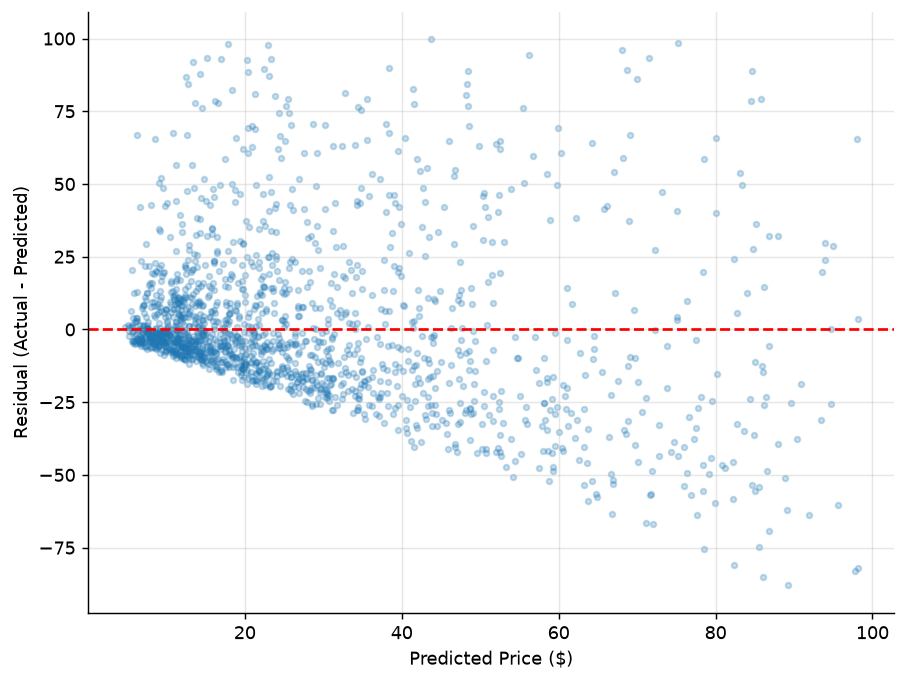

In [26]:
actual = comparison['actual']
pred = comparison['predicted']
residual = actual - pred

mask = (
    (pred < 100) &
    (residual > -100) &
    (residual < 100)
)

plt.figure(figsize=(8,6))

plt.scatter(
    pred[mask],
    residual[mask],
    alpha=0.25,
    s=10
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)
plt.show()

## 7e Actual price vs Prediction error plot

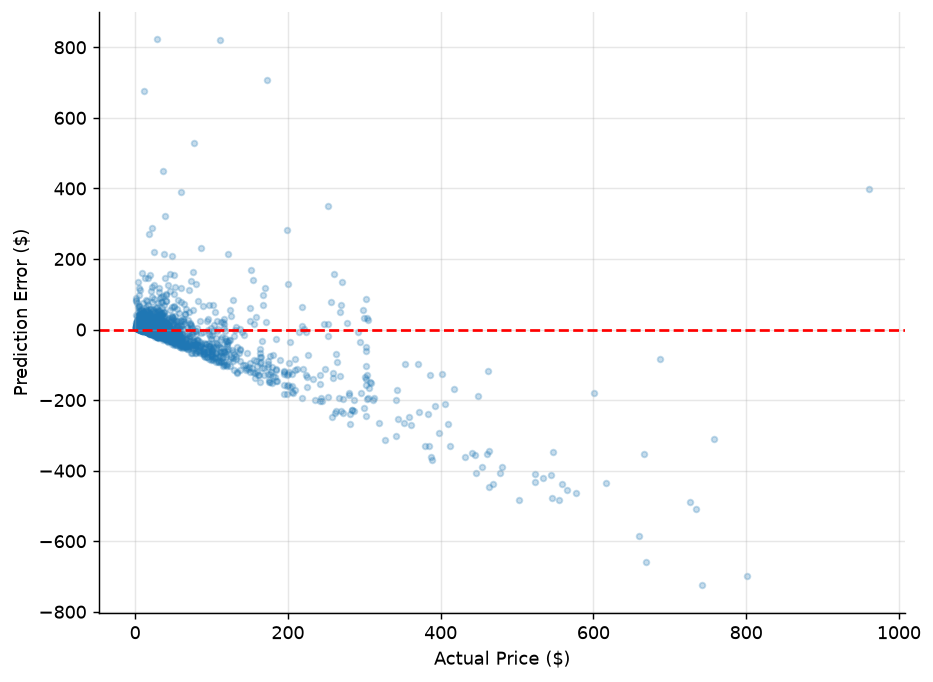

In [27]:
error = pred - actual

mask = (
    (actual < 1000) &
    (error > -1000) &
    (error < 1000)
)

plt.figure(figsize=(8,6))

plt.scatter(
    actual[mask],
    error[mask],
    alpha=0.25,
    s=10
)

plt.axhline(0, color="red", ls="--")

plt.xlabel("Actual Price ($)")
plt.ylabel("Prediction Error ($)")
plt.grid(alpha=0.3)

plt.show()

## 7f Compare actual vs predicted prices properties

In [28]:
bins = [0,10,20,30,40,50,75,100,np.inf]

df2 = pd.DataFrame({
    "actual": actual,
    "pred": pred,
})

df2["bin"] = pd.cut(df2["actual"], bins)

summary = df2.groupby("bin").agg(
    mean_actual=("actual", "mean"),
    mean_pred=("pred", "mean"),
)

# MAE
summary["mae"] = df2.groupby("bin").apply(
    lambda g: np.mean(np.abs(g["actual"] - g["pred"]))
)

# Mean Absolute Percentage Error (MAPE)
summary["mape"] = df2.groupby("bin").apply(
    lambda g: np.mean(
        np.abs(g["actual"] - g["pred"])
        / g["actual"].clip(lower=1)
    ) * 100
)

# Bias (positive = overpredict, negative = underpredict)
summary["bias"] = summary["mean_pred"] - summary["mean_actual"]

print(summary.round(2))



               mean_actual   mean_pred     mae    mape    bias
bin                                                           
(0.0, 10.0]           5.99   18.570000   12.70  293.28   12.58
(10.0, 20.0]         14.89   28.500000   16.16  114.87   13.61
(20.0, 30.0]         24.72   36.820000   22.01   88.39   12.10
(30.0, 40.0]         35.07   50.230000   30.32   85.90   15.16
(40.0, 50.0]         45.18   45.400002   26.52   58.69    0.22
(50.0, 75.0]         60.59   55.220001   36.57   60.68   -5.37
(75.0, 100.0]        87.00   62.209999   56.48   65.88  -24.79
(100.0, inf]        262.65  127.879997  175.64   63.17 -134.77


## 7g projects error sorted by error amount 

Clipped 221 rows (11.2%) beyond ±$100


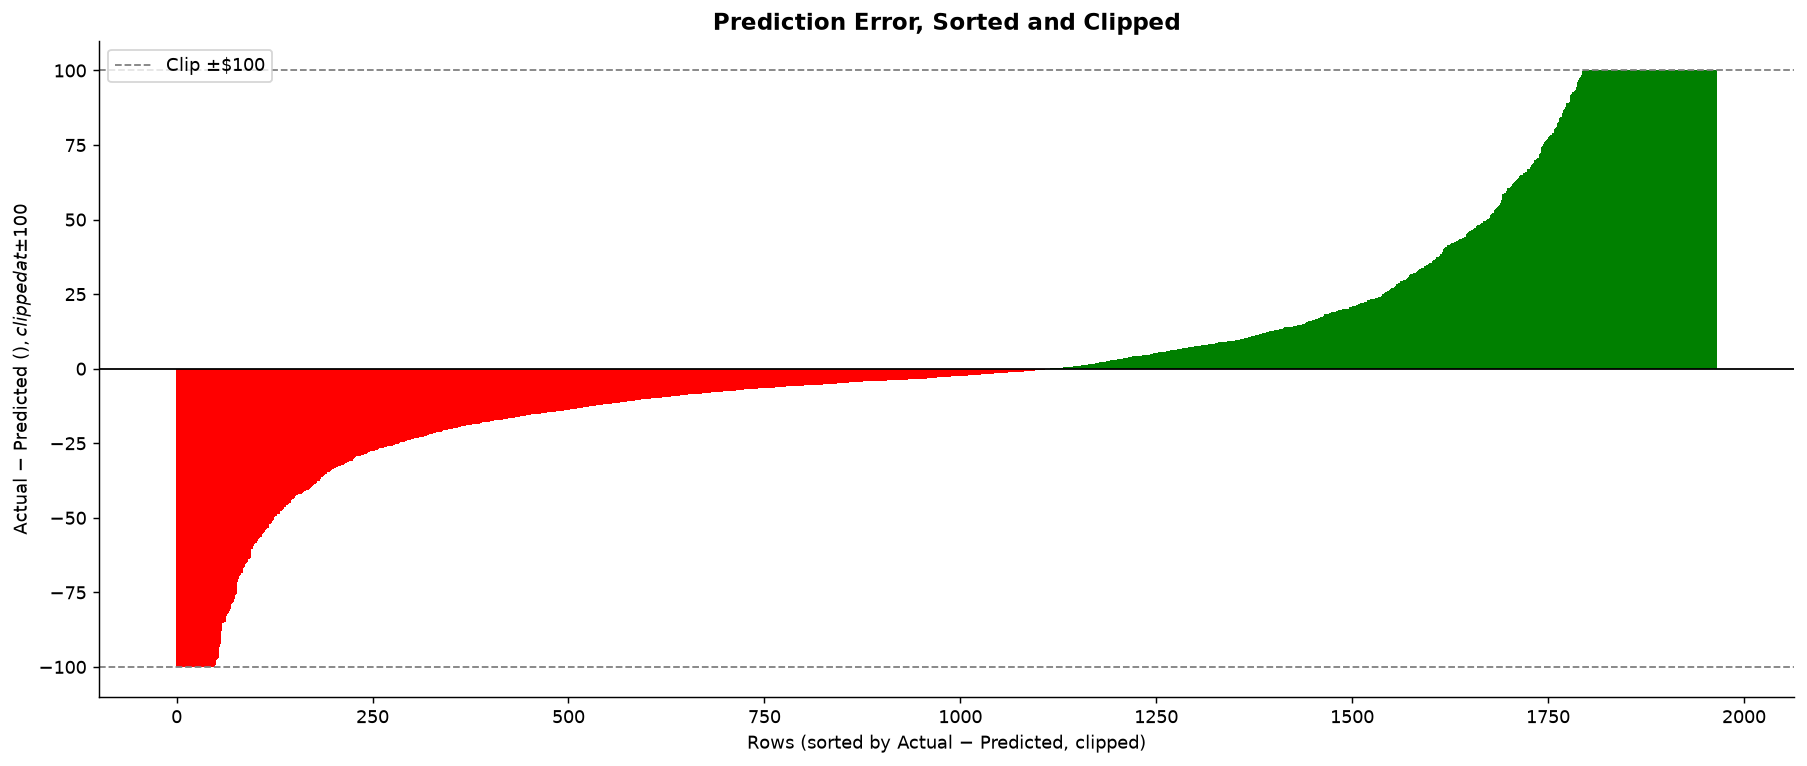

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Set your cap here — errors beyond this get clipped to the cap
# ============================================================
MAX_DIFF = 100   # adjust — try comparison['diff'].abs().quantile(0.95) to auto-pick

comparison['diff'] = comparison['actual'] - comparison['predicted']

# clip, don't drop — keeps every row, just caps the extreme values visually
comparison['diff_clipped'] = comparison['diff'].clip(-MAX_DIFF, MAX_DIFF)

n_clipped = (comparison['diff'].abs() > MAX_DIFF).sum()
print(f"Clipped {n_clipped} rows ({n_clipped/len(comparison):.1%}) beyond ±${MAX_DIFF:,}")

sorted_by_diff = comparison.sort_values('diff_clipped').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red' if d < 0 else 'green' for d in sorted_by_diff['diff_clipped']]
ax.bar(sorted_by_diff.index, sorted_by_diff['diff_clipped'], color=colors, width=1.0)

# mark the clip boundaries so it's clear where clipping kicks in
ax.axhline(MAX_DIFF, color='gray', linestyle='--', linewidth=1, label=f'Clip ±${MAX_DIFF:,}')
ax.axhline(-MAX_DIFF, color='gray', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=1)

ax.set_xlabel('Rows (sorted by Actual − Predicted, clipped)')
ax.set_ylabel(f'Actual − Predicted ($), clipped at ±${MAX_DIFF:,}')
ax.set_title('Prediction Error, Sorted and Clipped')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 8 Feature Importance

=== Budget model feature importance ===


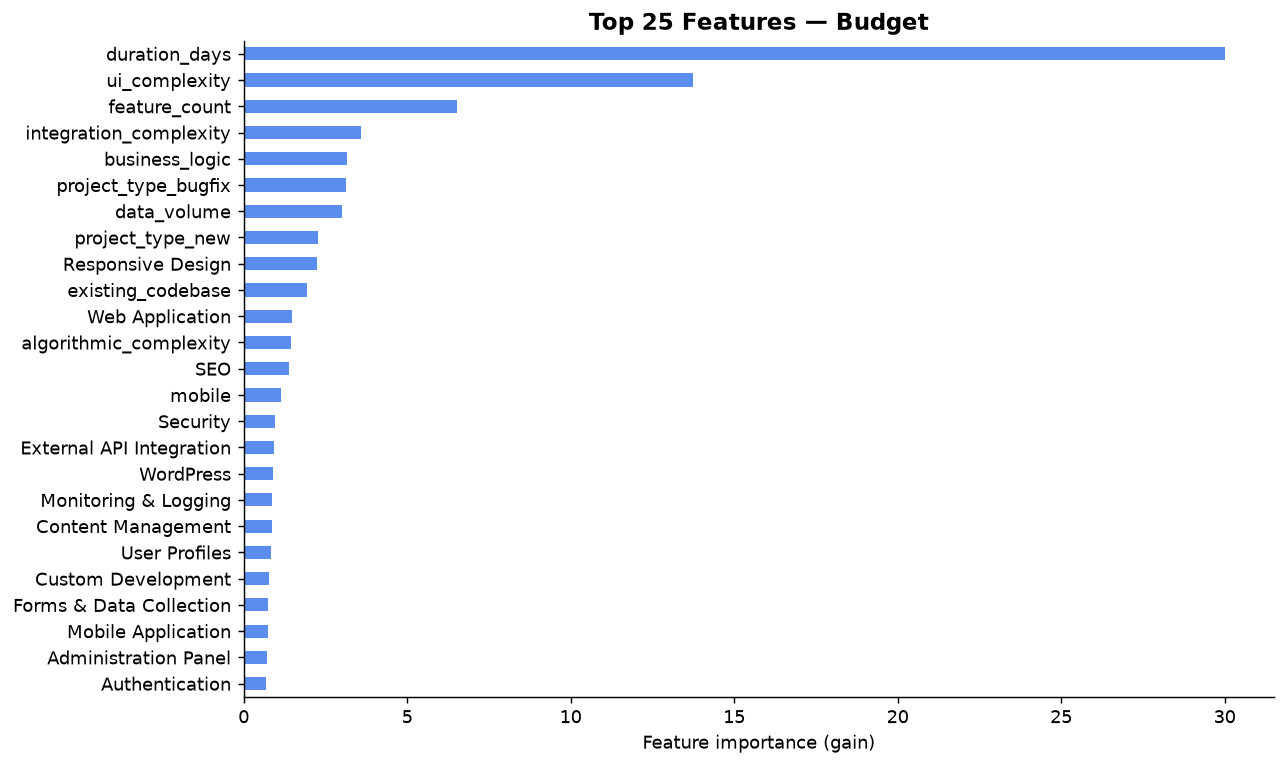

duration_days             30.007408
ui_complexity             13.742879
feature_count              6.534121
integration_complexity     3.573124
business_logic             3.173750
project_type_bugfix        3.124330
data_volume                3.003642
project_type_new           2.268295
Responsive Design          2.236501
existing_codebase          1.942247


In [30]:
TOP_N = 25

def plot_importance(model, feature_names, title, top_n=TOP_N):
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    else:
        return
    imp = imp.nlargest(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp[::-1].plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Feature importance (gain)')
    plt.tight_layout(); plt.show()
    return imp

print('=== Budget model feature importance ===')
imp_b = plot_importance(cat_none['model'], ALL_FEATURES, f'Top {TOP_N} Features — Budget')
print(imp_b.head(10).to_string())



## 9 · SHAP — per-prediction explanations
SHAP shows **why** the model made each prediction, not just which features matter on average.

Computing SHAP values for budget model...


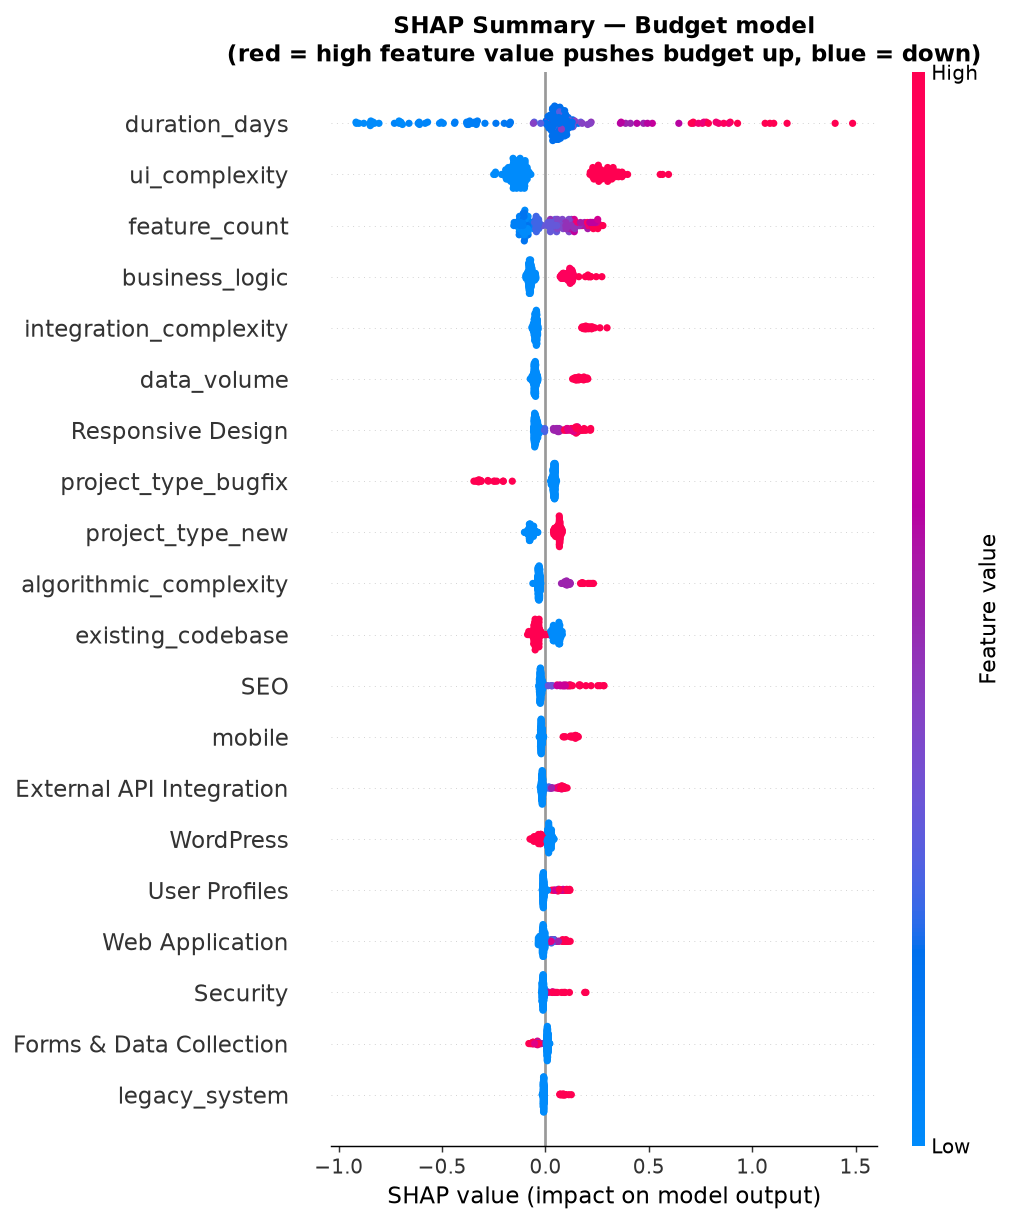

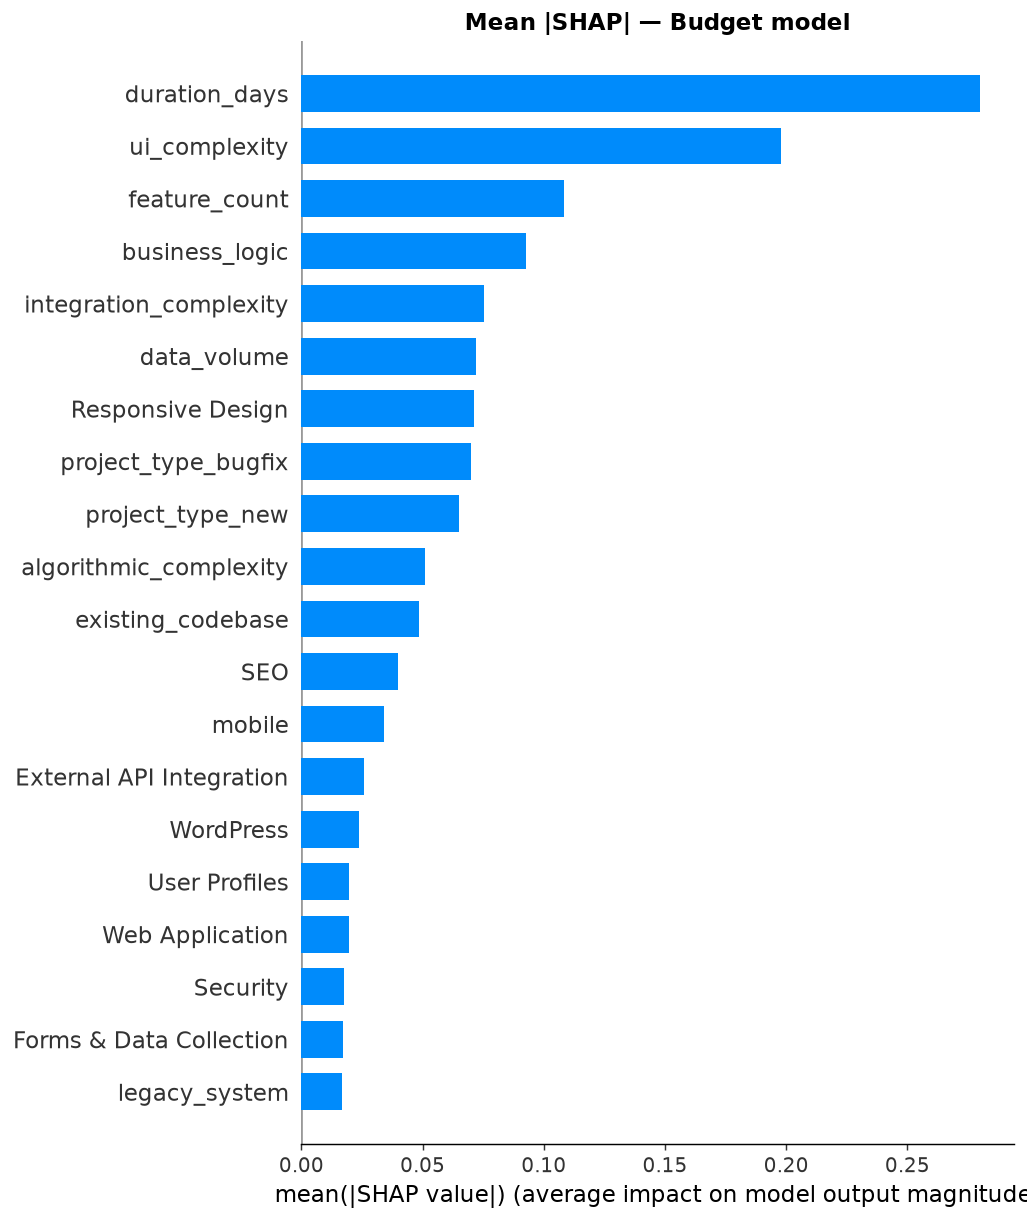


Explaining prediction for sample index 7 (predicted budget: 396)


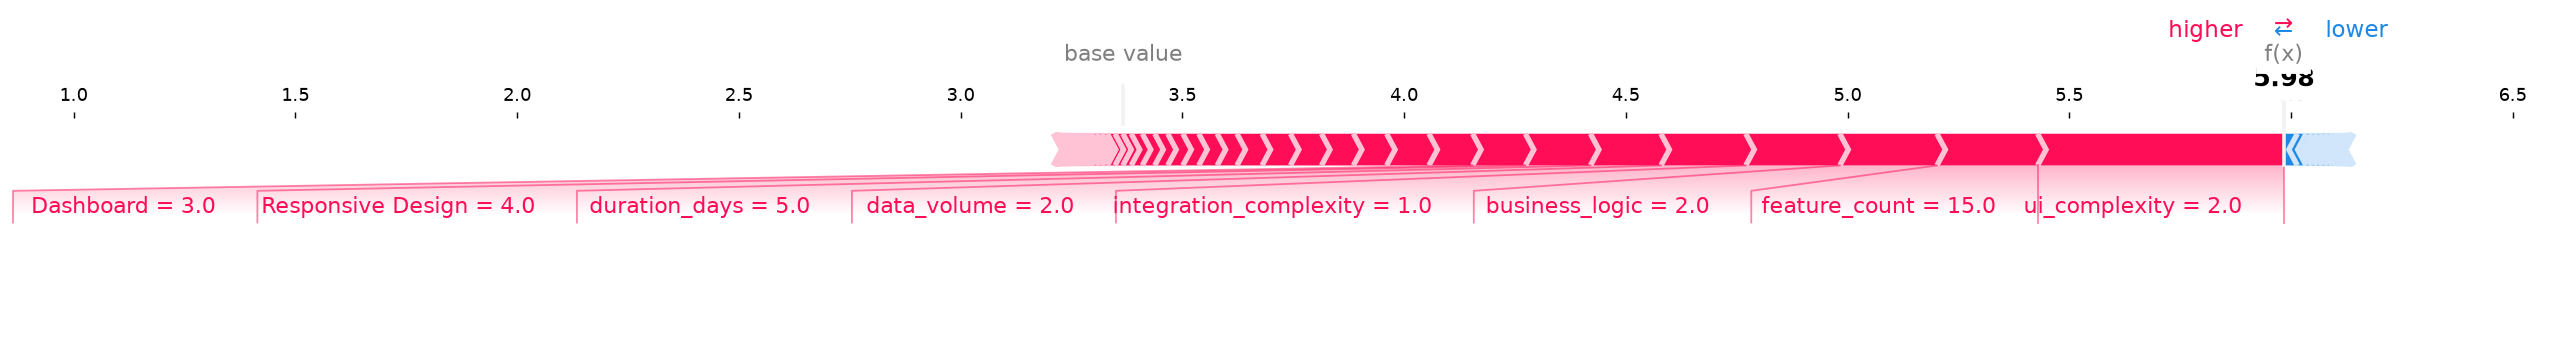

In [31]:
# Use a subsample for speed (SHAP is O(n * features) per call)
SHAP_SAMPLE = min(200, len(X_te))
X_shap = X_te.sample(SHAP_SAMPLE, random_state=42)

print('Computing SHAP values for budget model...')
explainer_b = shap.TreeExplainer(cat_none['model'])
shap_vals_b = explainer_b.shap_values(X_shap)

# Summary plot — global view: which features drive predictions most?
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  max_display=20, show=False)
plt.title('SHAP Summary — Budget model\n(red = high feature value pushes budget up, blue = down)')
plt.tight_layout(); plt.show()

# Bar plot — mean |SHAP| per feature
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP| — Budget model')
plt.tight_layout(); plt.show()

# Single prediction explanation (most expensive predicted project)
idx = np.argmax(np.expm1(cat_none['model'].predict(X_shap)))
print(f'\nExplaining prediction for sample index {idx} '
      f'(predicted budget: {np.expm1(cat_none["model"].predict(X_shap.iloc[[idx]])[0]):,.0f})')
shap.force_plot(explainer_b.expected_value, shap_vals_b[idx], X_shap.iloc[idx],
                feature_names=ALL_FEATURES, matplotlib=True, show=False)
plt.tight_layout(); plt.show()